# Imports & Config

In [8]:
import pandas as pd
import pickle
import dill
import time
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
import lightgbm as lgb
from scipy.stats import ks_2samp
from collections import Counter


RANDOM_SEED = 42
# выбрал glob т.к. он самый простой для шаблонного поиска
files = sorted(
    glob.glob("train_data/*.pq"),
    key=lambda x: int(x.split("_")[-1].replace(".pq", ""))
)
final_file = 'df_final.pq'

In [7]:
files

['train_data\\train_data_0.pq',
 'train_data\\train_data_1.pq',
 'train_data\\train_data_2.pq',
 'train_data\\train_data_3.pq',
 'train_data\\train_data_4.pq',
 'train_data\\train_data_5.pq',
 'train_data\\train_data_6.pq',
 'train_data\\train_data_7.pq',
 'train_data\\train_data_8.pq',
 'train_data\\train_data_9.pq',
 'train_data\\train_data_10.pq',
 'train_data\\train_data_11.pq']

# Data Loading

## Checking | Task 1

In [3]:
df_check = pd.read_parquet(files[0])
df_check.head()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,...,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,...,3,3,3,4,1,3,4,1,0,0


In [8]:
df_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974724 entries, 0 to 1974723
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90                    int64
 19  

In [2]:
cols_to_check = [
    # ВРЕМЕННЫЕ
    'pre_since_opened',
    'pre_since_confirmed',
    'pre_pterm',
    'pre_fterm',
    'pre_till_pclose',
    'pre_till_fclose',

    # ФИНАНСЫ
    'pre_loans_credit_limit',
    'pre_loans_next_pay_summ',
    'pre_loans_outstanding',
    'pre_loans_total_overdue',
    'pre_loans_max_overdue_sum',
    'pre_loans_credit_cost_rate',

    # ПРОСРОЧКИ
    'pre_loans5',
    'pre_loans530',
    'pre_loans3060',
    'pre_loans6090',
    'pre_loans90',

    # UTIL
    'pre_util',
    'pre_over2limit',
    'pre_maxover2limit',

    # ФЛАГИ
    'is_zero_loans5',
    'is_zero_loans530',
    'is_zero_loans3060',
    'is_zero_loans6090',
    'is_zero_loans90',
    'is_zero_util',
    'is_zero_over2limit',
    'is_zero_maxover2limit',
    'pclose_flag',
    'fclose_flag',

    # КАТЕГОРИИ
    'enc_loans_account_holder_type',
    'enc_loans_credit_status',
    'enc_loans_account_cur',
    'enc_loans_credit_type',
]

In [10]:
paym_cols = [c for c in df_check.columns if c.startswith('enc_paym_')]

cols_to_check += paym_cols

In [11]:
for col in cols_to_check:
    print(f'\n{"="*50}')
    print(f'Колонка: {col}')

    if col not in df_check.columns:
        print('❌ Нет такой колонки в df')
        continue

    nunique = df_check[col].nunique(dropna=False)
    print(f'nunique: {nunique}')

    vc = df_check[col].value_counts(normalize=True, dropna=False).head(10)

    print('\nTop-10 значений (доли):')
    print(vc)


Колонка: pre_since_opened
nunique: 20

Top-10 значений (доли):
pre_since_opened
18    0.080554
6     0.078102
13    0.071860
4     0.070018
8     0.067367
0     0.056378
7     0.048660
19    0.047722
2     0.046491
10    0.046091
Name: proportion, dtype: float64

Колонка: pre_since_confirmed
nunique: 18

Top-10 значений (доли):
pre_since_confirmed
9     0.212011
6     0.085673
14    0.067992
3     0.062580
17    0.059186
4     0.053914
8     0.051157
7     0.050463
13    0.042737
10    0.042421
Name: proportion, dtype: float64

Колонка: pre_pterm
nunique: 18

Top-10 значений (доли):
pre_pterm
4     0.189797
14    0.077209
7     0.064265
2     0.061662
16    0.055939
17    0.055656
8     0.055639
9     0.055590
1     0.054785
13    0.053356
Name: proportion, dtype: float64

Колонка: pre_fterm
nunique: 17

Top-10 значений (доли):
pre_fterm
8     0.231153
6     0.072576
9     0.065878
0     0.061676
16    0.059366
14    0.055244
10    0.051735
15    0.051616
2     0.051380
11    0.050370

Есть блоки с очень сильным доминирующим бином
Например:

pre_loans_outstanding — один бин ~80%
pre_util — один бин ~72%
pre_over2limit — один бин ~95%
pre_maxover2limit — один бин ~89%
pre_loans5/530/3060/6090/90 — почти полностью один бин
pre_loans_max_overdue_sum — один бин ~89%

Это значит, что для них сильнее всего будут работать признаки вида:

доля записей в доминирующем бине
был ли выход из доминирующего бина
число недоминантных состояний
число уникальных бинов
last bin / mode bin / mode share

Некоторые признаки почти константны
pre_loans_total_overdue — nunique = 1, всегда 0
Его можно смело выкинуть из агрегации целиком.

Блок enc_paym_* очень информативный

Тут видно явный временной рисунок:

ранние месяцы: доминирует 0
потом начинает доминировать 3
в некоторых колонках доминирует 4

Это значит, что enc_paym_* — сильный источник сигналов, но не через != 0 как “аномалию”, а через:

профиль статусов по месяцам
смену кодов
долю доминирующего кода
первый/последний код
число переключений



## loading

### Load function

#### Load function v5.0

load function 5.0 = v2.0 но без zero_cols

##### Class

In [259]:
class CreditHistoryAggregatorFast:
    def __init__(self, rare_threshold=0.05):
        self.rare_threshold = rare_threshold

        self.overdue_zero_cols = [
            'is_zero_loans5', 'is_zero_loans530',
            'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90'
        ]
        self.util_zero_cols = [
            'is_zero_util', 'is_zero_over2limit', 'is_zero_maxover2limit'
        ]
        self.loan_cat_cols = [
            'enc_loans_account_holder_type',
            'enc_loans_credit_status',
            # enc_loans_account_cur убран — first и last были в списке на удаление,
            # а remaining фичи имели нулевую важность
            'enc_loans_credit_type'
        ]
        self.selected_pre_cols = [
            'pre_since_opened',
            'pre_since_confirmed',
            'pre_loans_credit_limit',
            'pre_loans_next_pay_summ',
            'pre_loans_outstanding',
            'pre_loans_max_overdue_sum',
            'pre_loans_credit_cost_rate',
            'pre_util',
            'pre_over2limit',
            'pre_maxover2limit',
            # pre_loans6090 убран — все его фичи (nunique, first, last,
            #   change_count, changed_ever, share_global_mode, share_rare_bins)
            #   имели нулевую или незначительную важность
            # pre_loans90 убран — first, last, changed_ever имели нулевую важность
        ]

        self.value_counters_ = {col: Counter() for col in self.selected_pre_cols}
        self.paym_codes_      = set()
        self.global_mode_map_ = {}
        self.rare_bins_map_   = {}
        self.paym_cols_                   = []
        self.available_pre_cols_          = []
        self.available_loan_cat_cols_     = []
        self.available_overdue_zero_cols_ = []
        self.available_util_zero_cols_    = []
        self._finalized = False

    def update_global_stats(self, df):
        if not self.paym_cols_:
            self.paym_cols_ = sorted(
                [c for c in df.columns if c.startswith('enc_paym_')],
                key=lambda x: int(x.split('_')[-1])
            )
        if not self.available_pre_cols_:
            self.available_pre_cols_          = [c for c in self.selected_pre_cols if c in df.columns]
            self.available_loan_cat_cols_     = [c for c in self.loan_cat_cols if c in df.columns]
            self.available_overdue_zero_cols_ = [c for c in self.overdue_zero_cols if c in df.columns]
            self.available_util_zero_cols_    = [c for c in self.util_zero_cols if c in df.columns]
        for col in self.available_pre_cols_:
            vc = df[col].value_counts(dropna=False)
            self.value_counters_[col].update(vc.to_dict())
        for col in self.paym_cols_:
            self.paym_codes_.update(pd.unique(df[col].dropna()))

    def finalize_global_stats(self):
        for col in self.available_pre_cols_:
            counter = self.value_counters_[col]
            total   = sum(counter.values())
            if total == 0:
                self.global_mode_map_[col] = np.nan
                self.rare_bins_map_[col]   = set()
                continue
            sorted_items = sorted(counter.items(), key=lambda x: x[1], reverse=True)
            self.global_mode_map_[col] = sorted_items[0][0]
            self.rare_bins_map_[col]   = {
                k for k, v in counter.items()
                if (v / total) < self.rare_threshold
            }
        self.paym_codes_ = sorted(self.paym_codes_)
        self._finalized  = True

    @staticmethod
    def _change_count_fast(df, col):
        x       = df[['id', col]].copy()
        prev    = x.groupby('id')[col].shift(1)
        changed = (x[col] != prev).astype(np.int8)
        out     = changed.groupby(x['id']).sum() - 1
        out[out < 0] = 0
        return out

    def transform(self, df):
        if not self._finalized:
            raise RuntimeError("Сначала update_global_stats() и finalize_global_stats().")
        df    = df.sort_values(['id', 'rn']).reset_index(drop=True)
        parts = [self._build_base_features(df)]
        if self.available_overdue_zero_cols_:
            parts.append(self._build_overdue_features(df))
        if self.available_util_zero_cols_:
            parts.append(self._build_util_features(df))
        if self.available_loan_cat_cols_:
            parts.append(self._build_encoded_loan_features(df))
        if self.paym_cols_:
            parts.append(self._build_payment_features(df))
        if self.available_pre_cols_:
            parts.append(self._build_binned_pre_features(df))
        result = parts[0]
        for part in parts[1:]:
            result = result.merge(part, on='id', how='left')
        return result

    def _build_base_features(self, df):
        g   = df.groupby('id', sort=False)
        out = g.agg(
            num_credits=('rn', 'size'),
            max_rn     =('rn', 'max'),
            min_rn     =('rn', 'min'),
        ).reset_index()
        out['rn_span']         = out['max_rn'] - out['min_rn']
        out['is_single_credit'] = (out['num_credits'] == 1).astype(np.int8)
        out['rn_density']      = (
            out['num_credits'] / out['max_rn'].replace(0, np.nan)
        ).fillna(0)
        if 'pclose_flag' in df.columns:
            tmp = g['pclose_flag'].agg(['mean', 'max']).reset_index()
            tmp.columns = ['id', 'pclose_flag_share', 'pclose_flag_any']
            out = out.merge(tmp, on='id', how='left')
        if 'fclose_flag' in df.columns:
            tmp = g['fclose_flag'].agg(['mean', 'max']).reset_index()
            tmp.columns = ['id', 'fclose_flag_share', 'fclose_flag_any']
            out = out.merge(tmp, on='id', how='left')
        return out

    def _build_overdue_features(self, df):
        g          = df.groupby('id', sort=False)
        cols       = self.available_overdue_zero_cols_
        rename_map = {
            'is_zero_loans5'   : 'loans5',
            'is_zero_loans530' : 'loans530',
            'is_zero_loans3060': 'loans3060',
            'is_zero_loans6090': 'loans6090',
            'is_zero_loans90'  : 'loans90',
        }
        zero_share = g[cols].mean()
        zero_share.columns = [f'{rename_map[c]}_zero_share' for c in cols]
        overdue_share = 1 - zero_share
        overdue_share.columns = [
            c.replace('_zero_share', '_overdue_share') for c in zero_share.columns
        ]
        overdue_any = 1 - g[cols].min()
        overdue_any.columns = [f'{rename_map[c]}_has_overdue' for c in cols]
        overdue_count = g[cols].sum()
        overdue_count = g.size().to_frame('num_tmp').join(overdue_count)
        for c in cols:
            overdue_count[c] = overdue_count['num_tmp'] - overdue_count[c]
        overdue_count = overdue_count[cols]
        overdue_count.columns = [f'{rename_map[c]}_overdue_count' for c in cols]
        result = pd.concat([zero_share, overdue_share, overdue_any, overdue_count], axis=1)
        if {'is_zero_loans6090', 'is_zero_loans90'}.issubset(df.columns):
            serious_flag = (
                (1 - df['is_zero_loans6090']) | (1 - df['is_zero_loans90'])
            ).astype(np.int8)
            serious = serious_flag.groupby(df['id']).agg(['mean', 'max', 'sum'])
            serious.columns = ['share_serious_overdue', 'has_serious_overdue', 'count_serious_overdue']
            result = pd.concat([result, serious], axis=1)
        any_overdue = (1 - df[cols]).max(axis=1)
        any_overdue_agg = any_overdue.groupby(df['id']).agg(['mean', 'max', 'sum'])
        any_overdue_agg.columns = ['share_any_overdue', 'has_any_overdue', 'count_any_overdue']
        result = pd.concat([result, any_overdue_agg], axis=1)
        return result.reset_index()

    def _build_util_features(self, df):
        g          = df.groupby('id', sort=False)
        cols       = self.available_util_zero_cols_
        rename_map = {
            'is_zero_util'         : 'util',
            'is_zero_over2limit'   : 'over2limit',
            'is_zero_maxover2limit': 'maxover2limit',
        }
        zero_share = g[cols].mean()
        zero_share.columns = [f'{rename_map[c]}_zero_share' for c in cols]
        nonzero_share = 1 - zero_share
        nonzero_share.columns = [
            c.replace('_zero_share', '_nonzero_share') for c in zero_share.columns
        ]
        any_nonzero = 1 - g[cols].min()
        any_nonzero.columns = [f'{rename_map[c]}_has_nonzero' for c in cols]
        nonzero_count = g[cols].sum()
        nonzero_count = g.size().to_frame('num_tmp').join(nonzero_count)
        for c in cols:
            nonzero_count[c] = nonzero_count['num_tmp'] - nonzero_count[c]
        nonzero_count = nonzero_count[cols]
        nonzero_count.columns = [f'{rename_map[c]}_nonzero_count' for c in cols]
        return pd.concat([zero_share, nonzero_share, any_nonzero, nonzero_count], axis=1).reset_index()

    def _build_encoded_loan_features(self, df):
        out   = []
        g_all = df.groupby('id', sort=False)
        for col in self.available_loan_cat_cols_:
            tmp = g_all[col].agg(['nunique', 'first', 'last']).reset_index()
            tmp.columns = ['id', f'{col}_nunique', f'{col}_first', f'{col}_last']
            change_count = self._change_count_fast(df, col).rename(
                f'{col}_change_count'
            ).reset_index()
            tmp = tmp.merge(change_count, on='id', how='left')
            tmp[f'{col}_changed_ever'] = (tmp[f'{col}_change_count'] > 0).astype(np.int8)
            out.append(tmp)
        result = out[0]
        for part in out[1:]:
            result = result.merge(part, on='id', how='left')
        return result

    def _build_payment_features(self, df):
        paym = df[['id', 'rn'] + self.paym_cols_].copy()
        vals = paym[self.paym_cols_]
        paym['paym_row_nunique']      = vals.nunique(axis=1)
        paym['paym_row_change_count'] = (
            vals.iloc[:, 1:].values != vals.iloc[:, :-1].values
        ).sum(axis=1).astype(np.int16)
        paym['paym_row_first'] = vals.iloc[:, 0]
        paym['paym_row_last']  = vals.iloc[:, -1]
        top_codes = [c for c in [0, 1, 3, 4] if c in self.paym_codes_]
        for code in top_codes:
            paym[f'paym_row_share_code_{code}'] = (
                vals == code
            ).mean(axis=1).astype(np.float32)
        row_cols = [
            'paym_row_nunique',
            'paym_row_change_count',
            'paym_row_first',
            'paym_row_last',
        ] + [f'paym_row_share_code_{c}' for c in top_codes]
        agg = paym.groupby('id', sort=False)[row_cols].agg(['mean', 'max'])
        agg.columns = ['_'.join(col) for col in agg.columns]
        agg = agg.reset_index().fillna(0)
        return agg

    def _build_binned_pre_features(self, df):
        out   = []
        g_all = df.groupby('id', sort=False)

        # колонки для которых share_rare_bins оказался константным — не создаём
        cols_without_rare_bins = {
            'pre_since_confirmed',     # share_rare_bins была в списке на удаление
            'pre_loans_max_overdue_sum', # share_rare_bins была в списке на удаление
        }

        for col in self.available_pre_cols_:
            tmp = g_all[col].agg(['nunique', 'first', 'last']).reset_index()
            tmp.columns = ['id', f'{col}_nunique', f'{col}_first', f'{col}_last']

            # pre_loans90: убираем first и last — были в списке на удаление
            # оставляем только nunique, change_count
            if col == 'pre_loans90':
                tmp = tmp.drop(columns=[
                    'pre_loans90_first', 'pre_loans90_last'
                ], errors='ignore')

            # pre_loans3060: убираем first — был в списке на удаление
            if col == 'pre_loans3060':
                tmp = tmp.drop(columns=['pre_loans3060_first'], errors='ignore')

            change_count = self._change_count_fast(df, col).rename(
                f'{col}_change_count'
            ).reset_index()
            tmp = tmp.merge(change_count, on='id', how='left')

            # changed_ever убран для pre_loans90 — был в списке на удаление
            if col != 'pre_loans90':
                tmp[f'{col}_changed_ever'] = (
                    tmp[f'{col}_change_count'] > 0
                ).astype(np.int8)

            global_mode = self.global_mode_map_[col]
            rare_bins   = self.rare_bins_map_[col]

            share_global_mode = (
                (df[col] == global_mode)
                .groupby(df['id'])
                .mean()
                .rename(f'{col}_share_global_mode')
                .reset_index()
            )
            tmp = tmp.merge(share_global_mode, on='id', how='left')

            if col not in cols_without_rare_bins:
                share_rare_bins = (
                    df[col].isin(rare_bins)
                    .groupby(df['id'])
                    .mean()
                    .rename(f'{col}_share_rare_bins')
                    .reset_index()
                )
                tmp = tmp.merge(share_rare_bins, on='id', how='left')

            out.append(tmp)

        result = out[0]
        for part in out[1:]:
            result = result.merge(part, on='id', how='left')
        return result

##### Documentation

###### Общая логика

Исходные данные представляют собой историю кредитов клиента: 
каждая строка это один кредит в один момент времени. 
Для обучения модели необходимо агрегировать эту историю до уровня клиента (id).

Все признаки разделены на 6 блоков по смысловому содержанию.

Класс `CreditHistoryAggregatorFast` решает эту задачу итеративно:
сначала собирает глобальную статистику по всему датасету (`update_global_stats`, `finalize_global_stats`), затем применяет трансформацию к каждому батчу
(`transform`). Такой подход позволяет обрабатывать данные которые не помещаются
в оперативную память целиком.

###### Блок 1 Базовые характеристики

`num_credits` Общее число кредитов клиента — характеризует богатство кредитной истории

`max_rn` Номер последнего кредита — отражает длину истории

`pclose_flag_share` Доля кредитов без плановой даты закрытия — косвенный признак нестандартных продуктов

`fclose_flag_share` Доля кредитов без фактической даты закрытия — признак незакрытых обязательств

###### Блок 2 Просрочки по кредитам

`loans*_overdue_share`  Доля кредитов с просрочками данной категории — прямой сигнал риска

`loans*_overdue_count` Абсолютное число просрочек — важно в сочетании с долями

`share_serious_overdue` Доля серьёзных просрочек (60-90+ дней) — наиболее критичный сигнал дефолта

`count_serious_overdue` Число серьёзных просрочек — клиент с несколькими тяжёлыми просрочками значительно рискованнее

`share_any_overdue` Общая доля кредитов с любыми просрочками — интегральный показатель дисциплины

`has_any_overdue` Флаг наличия хотя бы одной просрочки — бинарный разделитель клиентов

`count_any_overdue` Общее число просрочек любой тяжести

###### Блок 3 Использование кредитного лимита

`util_nonzero_share` Доля кредитов с ненулевой утилизацией — активное использование лимита

`util_nonzero_count` Число кредитов с ненулевой утилизацией

`over2limit_nonzero_share` Доля кредитов с превышением лимита — прямой сигнал финансового стресса

`over2limit_nonzero_count` Число кредитов с превышением лимита

`maxover2limit_nonzero_share` Доля кредитов с максимальным превышением лимита

`maxover2limit_nonzero_count` Число кредитов с максимальным превышением

###### Блок 4 Категориальные характеристики кредитов

`enc_loans_account_holder_type_nunique` Число уникальных типов отношения к кредиту

`enc_loans_account_holder_type_change_count` Число смен типа — нестабильность кредитного профиля

`enc_loans_credit_status_*` Статус кредита (first/last/nunique/change_count) — динамика состояния портфеля

`enc_loans_credit_type_*` Тип кредита — разные типы несут разный уровень риска

`enc_loans_credit_type_changed_ever` Менял ли клиент тип кредита

###### Блок 5 Платёжное поведение

`paym_row_nunique_mean/max` Разнообразие платёжных статусов — нестабильное поведение сигнализирует о риске

`paym_row_change_count_mean/max` Число смен статуса — частые смены говорят о нестабильности

`paym_row_first_mean/max` Статус первого месяца — начальное состояние кредита

`paym_row_last_mean` Средний статус последнего месяца — текущее состояние важнее исторического

`paym_row_share_code_0/1/3/4_mean/max` Доля каждого кода платежа

###### Блок 6 Бинаризованные числовые признаки

`*_nunique` Число уникальных бинов — чем больше, тем активнее менялся показатель

`*_first` Значение при открытии первого кредита — начальное состояние

`*_last` Последнее значение — наиболее актуально для предсказания

`*_change_count` Число изменений — динамика показателя во времени

`*_share_global_mode` Доля записей в доминирующем бине — насколько типичен клиент относительно всей выборки

`*_share_rare_bins` Доля записей в редких бинах — аномальное поведение клиента

###### Блок 7 Производные признаки

`serious_to_mild_ratio` Отношение тяжёлых просрочек (90+ дней) к лёгким (до 5 дней) — эскалация проблем. Клиент у которого есть только тяжёлые просрочки значительно рискованнее клиента с лёгкими

`serious_overdue_fraction` Доля серьёзных просрочек среди всех — качество просрочек важнее их количества

`util_first_vs_last` Разница утилизации между первым и последним кредитом — растущая утилизация сигнализирует о нарастании финансовой нагрузки

`outstanding_trend` Тренд остатка долга — растущий долг признак ухудшения финансового положения

`credit_limit_trend` Изменение кредитного лимита — снижение лимита банком говорит о пересмотре риска клиента

###### Отбор признаков

После первичного обучения модели проведён анализ `feature_importances_`.
Признаки с нулевой и низкой важностью (importance < 20) были исключены
из агрегатора напрямую — чтобы не создавать их вовсе.

Итого удалено: признаки группы `enc_loans_account_cur` (нулевая важность),
`*_has_overdue` и `*_has_nonzero` (дублируют `overdue_share`),
`changed_ever` для большинства колонок, ряд `share_rare_bins` колонок
оказавшихся константными.

#### Load function v4.0 (not used)

##### Class

In [218]:
class CreditHistoryAggregatorFast:
    def __init__(self, rare_threshold=0.05):
        self.rare_threshold = rare_threshold
        self.overdue_zero_cols = [
            'is_zero_loans5', 'is_zero_loans530',
            'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90'
        ]
        self.util_zero_cols = [
            'is_zero_util', 'is_zero_over2limit', 'is_zero_maxover2limit'
        ]
        # убрали enc_loans_account_cur — все его фичи были в списке на удаление
        self.loan_cat_cols = [
            'enc_loans_account_holder_type',
            'enc_loans_credit_status',
            'enc_loans_credit_type'
        ]
        self.selected_pre_cols = [
            'pre_since_opened',
            'pre_since_confirmed',
            'pre_loans_credit_limit',
            'pre_loans_next_pay_summ',
            'pre_loans_outstanding',
            'pre_loans_max_overdue_sum',
            'pre_loans_credit_cost_rate',
            'pre_util',
            'pre_over2limit',
            'pre_maxover2limit',
        ]
        self.value_counters_ = {col: Counter() for col in self.selected_pre_cols}
        self.paym_codes_     = set()
        self.global_mode_map_ = {}
        self.rare_bins_map_   = {}
        self.paym_cols_                  = []
        self.available_pre_cols_         = []
        self.available_loan_cat_cols_    = []
        self.available_overdue_zero_cols_ = []
        self.available_util_zero_cols_   = []
        self._finalized = False
    def update_global_stats(self, df):
        if not self.paym_cols_:
            self.paym_cols_ = sorted(
                [c for c in df.columns if c.startswith('enc_paym_')],
                key=lambda x: int(x.split('_')[-1])
            )
        if not self.available_pre_cols_:
            self.available_pre_cols_          = [c for c in self.selected_pre_cols if c in df.columns]
            self.available_loan_cat_cols_     = [c for c in self.loan_cat_cols if c in df.columns]
            self.available_overdue_zero_cols_ = [c for c in self.overdue_zero_cols if c in df.columns]
            self.available_util_zero_cols_    = [c for c in self.util_zero_cols if c in df.columns]
        for col in self.available_pre_cols_:
            vc = df[col].value_counts(dropna=False)
            self.value_counters_[col].update(vc.to_dict())
        for col in self.paym_cols_:
            self.paym_codes_.update(pd.unique(df[col].dropna()))
    def finalize_global_stats(self):
        for col in self.available_pre_cols_:
            counter = self.value_counters_[col]
            total   = sum(counter.values())
            if total == 0:
                self.global_mode_map_[col] = np.nan
                self.rare_bins_map_[col]   = set()
                continue
            sorted_items = sorted(counter.items(), key=lambda x: x[1], reverse=True)
            self.global_mode_map_[col] = sorted_items[0][0]
            self.rare_bins_map_[col]   = {
                k for k, v in counter.items()
                if (v / total) < self.rare_threshold
            }
        self.paym_codes_ = sorted(self.paym_codes_)
        self._finalized  = True
    @staticmethod
    def _change_count_fast(df, col):
        x    = df[['id', col]].copy()
        prev = x.groupby('id')[col].shift(1)
        changed = (x[col] != prev).astype(np.int8)
        out = changed.groupby(x['id']).sum() - 1
        out[out < 0] = 0
        return out
    def transform(self, df):
        if not self._finalized:
            raise RuntimeError("Сначала вызови update_global_stats() и finalize_global_stats().")
        df    = df.sort_values(['id', 'rn']).reset_index(drop=True)
        parts = [self._build_base_features(df)]
        if self.available_overdue_zero_cols_:
            parts.append(self._build_overdue_features(df))
        if self.available_util_zero_cols_:
            parts.append(self._build_util_features(df))
        if self.available_loan_cat_cols_:
            parts.append(self._build_encoded_loan_features(df))
        if self.paym_cols_:
            parts.append(self._build_payment_features(df))
        if self.available_pre_cols_:
            parts.append(self._build_binned_pre_features(df))
        result = parts[0]
        for part in parts[1:]:
            result = result.merge(part, on='id', how='left')
        return result
    def _build_base_features(self, df):
        g   = df.groupby('id', sort=False)
        out = g.agg(
            num_credits=('rn', 'size'),
            max_rn     =('rn', 'max'),
            min_rn     =('rn', 'min'),
        ).reset_index()
        out['rn_span']   = out['max_rn'] - out['min_rn']
        # убрали is_single_credit — был в списке на удаление
        out['rn_density'] = (
            out['num_credits'] / out['max_rn'].replace(0, np.nan)
        ).fillna(0)
        if 'pclose_flag' in df.columns:
            tmp = g['pclose_flag'].agg(['mean']).reset_index()
            # убрали pclose_flag_any (max) — был в списке на удаление
            tmp.columns = ['id', 'pclose_flag_share']
            out = out.merge(tmp, on='id', how='left')
        if 'fclose_flag' in df.columns:
            tmp = g['fclose_flag'].agg(['mean']).reset_index()
            # убрали fclose_flag_any (max) — был в списке на удаление
            tmp.columns = ['id', 'fclose_flag_share']
            out = out.merge(tmp, on='id', how='left')
        return out
    def _build_overdue_features(self, df):
        g          = df.groupby('id', sort=False)
        cols       = self.available_overdue_zero_cols_
        rename_map = {
            'is_zero_loans5'   : 'loans5',
            'is_zero_loans530' : 'loans530',
            'is_zero_loans3060': 'loans3060',
            'is_zero_loans6090': 'loans6090',
            'is_zero_loans90'  : 'loans90',
        }
        zero_share = g[cols].mean()
        zero_share.columns = [f'{rename_map[c]}_zero_share' for c in cols]
        overdue_share = 1 - zero_share
        overdue_share.columns = [
            c.replace('_zero_share', '_overdue_share') for c in zero_share.columns
        ]
        # убрали overdue_any (*_has_overdue) — все были в списке на удаление
        overdue_count = g[cols].sum()
        overdue_count = g.size().to_frame('num_tmp').join(overdue_count)
        for c in cols:
            overdue_count[c] = overdue_count['num_tmp'] - overdue_count[c]
        overdue_count = overdue_count[cols]
        overdue_count.columns = [f'{rename_map[c]}_overdue_count' for c in cols]
        result = pd.concat([zero_share, overdue_share, overdue_count], axis=1)
        if {'is_zero_loans6090', 'is_zero_loans90'}.issubset(df.columns):
            serious_flag = (
                (1 - df['is_zero_loans6090']) | (1 - df['is_zero_loans90'])
            ).astype(np.int8)
            serious = serious_flag.groupby(df['id']).agg(['mean', 'sum'])
            # убрали has_serious_overdue (max) — был в списке на удаление
            serious.columns = ['share_serious_overdue', 'count_serious_overdue']
            result = pd.concat([result, serious], axis=1)
        any_overdue = (1 - df[cols]).max(axis=1)
        any_overdue_agg = any_overdue.groupby(df['id']).agg(['mean', 'max', 'sum'])
        any_overdue_agg.columns = ['share_any_overdue', 'has_any_overdue', 'count_any_overdue']
        result = pd.concat([result, any_overdue_agg], axis=1)
        return result.reset_index()
    def _build_util_features(self, df):
        g          = df.groupby('id', sort=False)
        cols       = self.available_util_zero_cols_
        rename_map = {
            'is_zero_util'         : 'util',
            'is_zero_over2limit'   : 'over2limit',
            'is_zero_maxover2limit': 'maxover2limit',
        }
        zero_share = g[cols].mean()
        zero_share.columns = [f'{rename_map[c]}_zero_share' for c in cols]
        nonzero_share = 1 - zero_share
        nonzero_share.columns = [
            c.replace('_zero_share', '_nonzero_share') for c in zero_share.columns
        ]
        # убрали any_nonzero (*_has_nonzero) — все были в списке на удаление
        nonzero_count = g[cols].sum()
        nonzero_count = g.size().to_frame('num_tmp').join(nonzero_count)
        for c in cols:
            nonzero_count[c] = nonzero_count['num_tmp'] - nonzero_count[c]
        nonzero_count = nonzero_count[cols]
        nonzero_count.columns = [f'{rename_map[c]}_nonzero_count' for c in cols]
        return pd.concat([zero_share, nonzero_share, nonzero_count], axis=1).reset_index()
    def _build_encoded_loan_features(self, df):
        out   = []
        g_all = df.groupby('id', sort=False)
        for col in self.available_loan_cat_cols_:
            # убрали first и last для enc_loans_account_holder_type — были в списке
            # оставляем nunique и change_count для всех
            tmp = g_all[col].agg(['nunique', 'first', 'last']).reset_index()
            tmp.columns = ['id', f'{col}_nunique', f'{col}_first', f'{col}_last']
            change_count = self._change_count_fast(df, col).rename(
                f'{col}_change_count'
            ).reset_index()
            tmp = tmp.merge(change_count, on='id', how='left')
            # убрали changed_ever для account_holder_type, credit_status — были в списке
            # оставляем только для enc_loans_credit_type
            if col == 'enc_loans_credit_type':
                tmp[f'{col}_changed_ever'] = (
                    tmp[f'{col}_change_count'] > 0
                ).astype(np.int8)
            # убрали first и last для enc_loans_account_holder_type
            if col == 'enc_loans_account_holder_type':
                tmp = tmp.drop(columns=[
                    f'{col}_first', f'{col}_last'
                ], errors='ignore')
            out.append(tmp)
        result = out[0]
        for part in out[1:]:
            result = result.merge(part, on='id', how='left')
        return result
    def _build_payment_features(self, df):
        paym = df[['id', 'rn'] + self.paym_cols_].copy()
        vals = paym[self.paym_cols_]
        paym['paym_row_nunique'] = vals.nunique(axis=1)
        paym['paym_row_change_count'] = (
            vals.iloc[:, 1:].values != vals.iloc[:, :-1].values
        ).sum(axis=1).astype(np.int16)
        paym['paym_row_first'] = vals.iloc[:, 0]
        paym['paym_row_last']  = vals.iloc[:, -1]
        top_codes = [c for c in [0, 1, 3, 4] if c in self.paym_codes_]
        for code in top_codes:
            paym[f'paym_row_share_code_{code}'] = (
                vals == code
            ).mean(axis=1).astype(np.float32)
        row_cols = [
            'paym_row_nunique',
            'paym_row_change_count',
            'paym_row_first',
            'paym_row_last',
        ] + [f'paym_row_share_code_{c}' for c in top_codes]
        agg = paym.groupby('id', sort=False)[row_cols].agg(['mean', 'max'])
        agg.columns = ['_'.join(col) for col in agg.columns]
        agg = agg.reset_index().fillna(0)
        # убрали paym_row_last_max — был в списке на удаление
        agg = agg.drop(columns=['paym_row_last_max'], errors='ignore')
        return agg
    def _build_binned_pre_features(self, df):
        out   = []
        g_all = df.groupby('id', sort=False)
        for col in self.available_pre_cols_:
            tmp = g_all[col].agg(['nunique', 'first', 'last']).reset_index()
            tmp.columns = ['id', f'{col}_nunique', f'{col}_first', f'{col}_last']
            change_count = self._change_count_fast(df, col).rename(
                f'{col}_change_count'
            ).reset_index()
            tmp = tmp.merge(change_count, on='id', how='left')
            # убрали changed_ever для всех pre_* — были в списке на удаление
            # убрали share_rare_bins для pre_fterm, pre_loans_max_overdue_sum,
            #   pre_since_confirmed — были в списке на удаление
            global_mode = self.global_mode_map_[col]
            rare_bins   = self.rare_bins_map_[col]
            share_global_mode = (
                (df[col] == global_mode)
                .groupby(df['id'])
                .mean()
                .rename(f'{col}_share_global_mode')
                .reset_index()
            )
            tmp = tmp.merge(share_global_mode, on='id', how='left')
            # share_rare_bins добавляем только для колонок не в списке на удаление
            cols_without_rare_bins = {
                'pre_fterm',
                'pre_loans_max_overdue_sum',
                'pre_since_confirmed',
                'min_rn',
                'rn_density',
                'pre_since_opened',
                'pre_till_pclose',
                'pre_loans_next_pay_summ',
                'pre_loans_outstanding'
            }
            if col not in cols_without_rare_bins:
                share_rare_bins = (
                    df[col].isin(rare_bins)
                    .groupby(df['id'])
                    .mean()
                    .rename(f'{col}_share_rare_bins')
                    .reset_index()
                )
                tmp = tmp.merge(share_rare_bins, on='id', how='left')
            out.append(tmp)
        result = out[0]
        for part in out[1:]:
            result = result.merge(part, on='id', how='left')
        return result

#### Load function v3.0   (без мультиколлинеарности но меньше метрика)((not used))

##### Class

In [103]:
class CreditHistoryAggregatorFast:
    def __init__(self, rare_threshold=0.05):
        self.rare_threshold = rare_threshold

        self.overdue_zero_cols = [
            'is_zero_loans5', 'is_zero_loans530',
            'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90'
        ]
        self.util_zero_cols = [
            'is_zero_util', 'is_zero_over2limit', 'is_zero_maxover2limit'
        ]
        # убрали enc_loans_account_cur — все его фичи были в списке на удаление
        self.loan_cat_cols = [
            'enc_loans_account_holder_type',
            'enc_loans_credit_status',
            'enc_loans_credit_type'
        ]
        self.selected_pre_cols = [
            'pre_since_opened',
            'pre_since_confirmed',
            'pre_loans_credit_limit',
            'pre_loans_next_pay_summ',
            'pre_loans_outstanding',
            'pre_loans_max_overdue_sum',
            'pre_loans_credit_cost_rate',
            'pre_util',
            'pre_over2limit',
            'pre_maxover2limit',
        ]
        self.value_counters_ = {col: Counter() for col in self.selected_pre_cols}
        self.paym_codes_     = set()
        self.global_mode_map_ = {}
        self.rare_bins_map_   = {}
        self.paym_cols_                  = []
        self.available_pre_cols_         = []
        self.available_loan_cat_cols_    = []
        self.available_overdue_zero_cols_ = []
        self.available_util_zero_cols_   = []
        self._finalized = False

    def update_global_stats(self, df):
        if not self.paym_cols_:
            self.paym_cols_ = sorted(
                [c for c in df.columns if c.startswith('enc_paym_')],
                key=lambda x: int(x.split('_')[-1])
            )
        if not self.available_pre_cols_:
            self.available_pre_cols_          = [c for c in self.selected_pre_cols if c in df.columns]
            self.available_loan_cat_cols_     = [c for c in self.loan_cat_cols if c in df.columns]
            self.available_overdue_zero_cols_ = [c for c in self.overdue_zero_cols if c in df.columns]
            self.available_util_zero_cols_    = [c for c in self.util_zero_cols if c in df.columns]
        for col in self.available_pre_cols_:
            vc = df[col].value_counts(dropna=False)
            self.value_counters_[col].update(vc.to_dict())
        for col in self.paym_cols_:
            self.paym_codes_.update(pd.unique(df[col].dropna()))

    def finalize_global_stats(self):
        for col in self.available_pre_cols_:
            counter = self.value_counters_[col]
            total   = sum(counter.values())
            if total == 0:
                self.global_mode_map_[col] = np.nan
                self.rare_bins_map_[col]   = set()
                continue
            sorted_items = sorted(counter.items(), key=lambda x: x[1], reverse=True)
            self.global_mode_map_[col] = sorted_items[0][0]
            self.rare_bins_map_[col]   = {
                k for k, v in counter.items()
                if (v / total) < self.rare_threshold
            }
        self.paym_codes_ = sorted(self.paym_codes_)
        self._finalized  = True

    @staticmethod
    def _change_count_fast(df, col):
        x    = df[['id', col]].copy()
        prev = x.groupby('id')[col].shift(1)
        changed = (x[col] != prev).astype(np.int8)
        out = changed.groupby(x['id']).sum() - 1
        out[out < 0] = 0
        return out

    def transform(self, df):
        if not self._finalized:
            raise RuntimeError("Сначала вызови update_global_stats() и finalize_global_stats().")
        df    = df.sort_values(['id', 'rn']).reset_index(drop=True)
        parts = [self._build_base_features(df)]
        if self.available_overdue_zero_cols_:
            parts.append(self._build_overdue_features(df))
        if self.available_util_zero_cols_:
            parts.append(self._build_util_features(df))
        if self.available_loan_cat_cols_:
            parts.append(self._build_encoded_loan_features(df))
        if self.paym_cols_:
            parts.append(self._build_payment_features(df))
        if self.available_pre_cols_:
            parts.append(self._build_binned_pre_features(df))
        result = parts[0]
        for part in parts[1:]:
            result = result.merge(part, on='id', how='left')
        return result

    def _build_base_features(self, df):
        g   = df.groupby('id', sort=False)
        out = g.agg(
            num_credits=('rn', 'size'),
            max_rn     =('rn', 'max'),
        ).reset_index()
        # убрали rn_span — коррелирует с max_rn и num_credits
        # убрали min_rn — константа или коррелирует
        if 'pclose_flag' in df.columns:
            tmp = g['pclose_flag'].agg(['mean']).reset_index()
            tmp.columns = ['id', 'pclose_flag_share']
            out = out.merge(tmp, on='id', how='left')
        if 'fclose_flag' in df.columns:
            tmp = g['fclose_flag'].agg(['mean']).reset_index()
            tmp.columns = ['id', 'fclose_flag_share']
            out = out.merge(tmp, on='id', how='left')
        return out

    def _build_overdue_features(self, df):
        g          = df.groupby('id', sort=False)
        cols       = self.available_overdue_zero_cols_
        rename_map = {
            'is_zero_loans5'   : 'loans5',
            'is_zero_loans530' : 'loans530',
            'is_zero_loans3060': 'loans3060',
            'is_zero_loans6090': 'loans6090',
            'is_zero_loans90'  : 'loans90',
        }
        # убрали zero_share — это 1 - overdue_share, прямой дубль
        overdue_share = 1 - g[cols].mean()
        overdue_share.columns = [f'{rename_map[c]}_overdue_share' for c in cols]
    
        overdue_count = g[cols].sum()
        overdue_count = g.size().to_frame('num_tmp').join(overdue_count)
        for c in cols:
            overdue_count[c] = overdue_count['num_tmp'] - overdue_count[c]
        overdue_count = overdue_count[cols]
        overdue_count.columns = [f'{rename_map[c]}_overdue_count' for c in cols]
    
        result = pd.concat([overdue_share, overdue_count], axis=1)
    
        if {'is_zero_loans6090', 'is_zero_loans90'}.issubset(df.columns):
            serious_flag = (
                (1 - df['is_zero_loans6090']) | (1 - df['is_zero_loans90'])
            ).astype(np.int8)
            serious = serious_flag.groupby(df['id']).agg(['mean', 'sum'])
            serious.columns = ['share_serious_overdue', 'count_serious_overdue']
            result = pd.concat([result, serious], axis=1)
    
        any_overdue = (1 - df[cols]).max(axis=1)
        any_overdue_agg = any_overdue.groupby(df['id']).agg(['mean', 'max', 'sum'])
        any_overdue_agg.columns = ['share_any_overdue', 'has_any_overdue', 'count_any_overdue']
        result = pd.concat([result, any_overdue_agg], axis=1)
    
        return result.reset_index()

    def _build_util_features(self, df):
        g          = df.groupby('id', sort=False)
        cols       = self.available_util_zero_cols_
        rename_map = {
            'is_zero_util'         : 'util',
            'is_zero_over2limit'   : 'over2limit',
            'is_zero_maxover2limit': 'maxover2limit',
        }
        # убрали zero_share — это 1 - nonzero_share, прямой дубль
        nonzero_share = 1 - g[cols].mean()
        nonzero_share.columns = [f'{rename_map[c]}_nonzero_share' for c in cols]
    
        nonzero_count = g[cols].sum()
        nonzero_count = g.size().to_frame('num_tmp').join(nonzero_count)
        for c in cols:
            nonzero_count[c] = nonzero_count['num_tmp'] - nonzero_count[c]
        nonzero_count = nonzero_count[cols]
        nonzero_count.columns = [f'{rename_map[c]}_nonzero_count' for c in cols]
    
        return pd.concat([nonzero_share, nonzero_count], axis=1).reset_index()

    def _build_encoded_loan_features(self, df):
        out   = []
        g_all = df.groupby('id', sort=False)

        for col in self.available_loan_cat_cols_:
            # убрали first и last для enc_loans_account_holder_type — были в списке
            # оставляем nunique и change_count для всех
            tmp = g_all[col].agg(['nunique', 'first', 'last']).reset_index()
            tmp.columns = ['id', f'{col}_nunique', f'{col}_first', f'{col}_last']

            change_count = self._change_count_fast(df, col).rename(
                f'{col}_change_count'
            ).reset_index()
            tmp = tmp.merge(change_count, on='id', how='left')
            # убрали changed_ever для account_holder_type, credit_status — были в списке
            # оставляем только для enc_loans_credit_type
            if col == 'enc_loans_credit_type':
                tmp[f'{col}_changed_ever'] = (
                    tmp[f'{col}_change_count'] > 0
                ).astype(np.int8)

            # убрали first и last для enc_loans_account_holder_type
            if col == 'enc_loans_account_holder_type':
                tmp = tmp.drop(columns=[
                    f'{col}_first', f'{col}_last'
                ], errors='ignore')

            out.append(tmp)

        result = out[0]
        for part in out[1:]:
            result = result.merge(part, on='id', how='left')
        return result

    def _build_payment_features(self, df):
        paym = df[['id', 'rn'] + self.paym_cols_].copy()
        vals = paym[self.paym_cols_]

        paym['paym_row_nunique'] = vals.nunique(axis=1)
        paym['paym_row_change_count'] = (
            vals.iloc[:, 1:].values != vals.iloc[:, :-1].values
        ).sum(axis=1).astype(np.int16)
        paym['paym_row_first'] = vals.iloc[:, 0]
        paym['paym_row_last']  = vals.iloc[:, -1]

        top_codes = [c for c in [0, 1, 3, 4] if c in self.paym_codes_]
        for code in top_codes:
            paym[f'paym_row_share_code_{code}'] = (
                vals == code
            ).mean(axis=1).astype(np.float32)

        row_cols = [
            'paym_row_nunique',
            'paym_row_change_count',
            'paym_row_first',
            'paym_row_last',
        ] + [f'paym_row_share_code_{c}' for c in top_codes]

        agg = paym.groupby('id', sort=False)[row_cols].agg(['mean', 'max'])
        agg.columns = ['_'.join(col) for col in agg.columns]
        agg = agg.reset_index().fillna(0)

        # убрали paym_row_last_max — был в списке на удаление
        agg = agg.drop(columns=['paym_row_last_max'], errors='ignore')

        return agg

    def _build_binned_pre_features(self, df):
        out   = []
        g_all = df.groupby('id', sort=False)

        for col in self.available_pre_cols_:
            tmp = g_all[col].agg(['nunique', 'first', 'last']).reset_index()
            tmp.columns = ['id', f'{col}_nunique', f'{col}_first', f'{col}_last']

            change_count = self._change_count_fast(df, col).rename(
                f'{col}_change_count'
            ).reset_index()
            tmp = tmp.merge(change_count, on='id', how='left')

            # убрали changed_ever для всех pre_* — были в списке на удаление
            # убрали share_rare_bins для pre_fterm, pre_loans_max_overdue_sum,
            #   pre_since_confirmed — были в списке на удаление

            global_mode = self.global_mode_map_[col]
            rare_bins   = self.rare_bins_map_[col]

            share_global_mode = (
                (df[col] == global_mode)
                .groupby(df['id'])
                .mean()
                .rename(f'{col}_share_global_mode')
                .reset_index()
            )
            tmp = tmp.merge(share_global_mode, on='id', how='left')

            # share_rare_bins добавляем только для колонок не в списке на удаление
            cols_without_rare_bins = {
                'pre_fterm',
                'pre_loans_max_overdue_sum',
                'pre_since_confirmed',
                'min_rn',
                'rn_density',
                'pre_since_opened',
                'pre_till_pclose',
                'pre_loans_next_pay_summ',
                'pre_loans_outstanding'
            }
            if col not in cols_without_rare_bins:
                share_rare_bins = (
                    df[col].isin(rare_bins)
                    .groupby(df['id'])
                    .mean()
                    .rename(f'{col}_share_rare_bins')
                    .reset_index()
                )
                tmp = tmp.merge(share_rare_bins, on='id', how='left')

            out.append(tmp)

        result = out[0]
        for part in out[1:]:
            result = result.merge(part, on='id', how='left')
        return result

#### Load Funciton v2.0 (not used)

In [14]:
class CreditHistoryAggregatorFast:
    def __init__(self, rare_threshold=0.05):
        self.rare_threshold = rare_threshold

        self.overdue_zero_cols = [
            'is_zero_loans5', 'is_zero_loans530',
            'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90'
        ]

        self.util_zero_cols = [
            'is_zero_util', 'is_zero_over2limit', 'is_zero_maxover2limit'
        ]

        self.loan_cat_cols = [
            'enc_loans_account_holder_type',
            'enc_loans_credit_status',
            'enc_loans_account_cur',
            'enc_loans_credit_type'
        ]

        # сократил список pre_* до самых полезных
        self.selected_pre_cols = [
            'pre_since_opened',
            'pre_since_confirmed',
            'pre_loans_credit_limit',
            'pre_loans_next_pay_summ',
            'pre_loans_outstanding',
            'pre_loans_max_overdue_sum',
            'pre_loans_credit_cost_rate',
            'pre_util',
            'pre_over2limit',
            'pre_maxover2limit',
        ]

        self.value_counters_ = {col: Counter() for col in self.selected_pre_cols}
        self.paym_codes_ = set()

        self.global_mode_map_ = {}
        self.rare_bins_map_ = {}
        self.paym_cols_ = []
        self.available_pre_cols_ = []
        self.available_loan_cat_cols_ = []
        self.available_overdue_zero_cols_ = []
        self.available_util_zero_cols_ = []
        self._finalized = False

    def update_global_stats(self, df):
        if not self.paym_cols_:
            self.paym_cols_ = sorted(
                [c for c in df.columns if c.startswith('enc_paym_')],
                key=lambda x: int(x.split('_')[-1])
            )

        if not self.available_pre_cols_:
            self.available_pre_cols_ = [c for c in self.selected_pre_cols if c in df.columns]
            self.available_loan_cat_cols_ = [c for c in self.loan_cat_cols if c in df.columns]
            self.available_overdue_zero_cols_ = [c for c in self.overdue_zero_cols if c in df.columns]
            self.available_util_zero_cols_ = [c for c in self.util_zero_cols if c in df.columns]

        for col in self.available_pre_cols_:
            vc = df[col].value_counts(dropna=False)
            self.value_counters_[col].update(vc.to_dict())

        # только уникальные payment codes
        for col in self.paym_cols_:
            self.paym_codes_.update(pd.unique(df[col].dropna()))

    def finalize_global_stats(self):
        for col in self.available_pre_cols_:
            counter = self.value_counters_[col]
            total = sum(counter.values())

            if total == 0:
                self.global_mode_map_[col] = np.nan
                self.rare_bins_map_[col] = set()
                continue

            sorted_items = sorted(counter.items(), key=lambda x: x[1], reverse=True)
            self.global_mode_map_[col] = sorted_items[0][0]
            self.rare_bins_map_[col] = {
                k for k, v in counter.items()
                if (v / total) < self.rare_threshold
            }

        self.paym_codes_ = sorted(self.paym_codes_)
        self._finalized = True

    @staticmethod
    def _change_count_fast(df, col):
        x = df[['id', col]].copy()
        prev = x.groupby('id')[col].shift(1)
        changed = (x[col] != prev).astype(np.int8)
        out = changed.groupby(x['id']).sum() - 1
        out[out < 0] = 0
        return out

    def transform(self, df):
        if not self._finalized:
            raise RuntimeError("Сначала update_global_stats(...) по всем train-файлам и finalize_global_stats().")

        df = df.sort_values(['id', 'rn']).reset_index(drop=True)

        parts = [self._build_base_features(df)]

        if self.available_overdue_zero_cols_:
            parts.append(self._build_overdue_features(df))

        if self.available_util_zero_cols_:
            parts.append(self._build_util_features(df))

        if self.available_loan_cat_cols_:
            parts.append(self._build_encoded_loan_features(df))

        if self.paym_cols_:
            parts.append(self._build_payment_features(df))

        if self.available_pre_cols_:
            parts.append(self._build_binned_pre_features(df))

        result = parts[0]
        for part in parts[1:]:
            result = result.merge(part, on='id', how='left')

        return result

    def _build_base_features(self, df):
        g = df.groupby('id', sort=False)

        out = g.agg(
            num_credits=('rn', 'size'),
            max_rn=('rn', 'max'),
            min_rn=('rn', 'min'),
        ).reset_index()

        out['rn_span'] = out['max_rn'] - out['min_rn']
        out['is_single_credit'] = (out['num_credits'] == 1).astype(np.int8)
        out['rn_density'] = (out['num_credits'] / out['max_rn'].replace(0, np.nan)).fillna(0)

        if 'pclose_flag' in df.columns:
            tmp = g['pclose_flag'].agg(['mean', 'max']).reset_index()
            tmp.columns = ['id', 'pclose_flag_share', 'pclose_flag_any']
            out = out.merge(tmp, on='id', how='left')

        if 'fclose_flag' in df.columns:
            tmp = g['fclose_flag'].agg(['mean', 'max']).reset_index()
            tmp.columns = ['id', 'fclose_flag_share', 'fclose_flag_any']
            out = out.merge(tmp, on='id', how='left')

        return out

    def _build_overdue_features(self, df):
        g = df.groupby('id', sort=False)
        cols = self.available_overdue_zero_cols_

        rename_map = {
            'is_zero_loans5': 'loans5',
            'is_zero_loans530': 'loans530',
            'is_zero_loans3060': 'loans3060',
            'is_zero_loans6090': 'loans6090',
            'is_zero_loans90': 'loans90',
        }

        zero_share = g[cols].mean()
        zero_share.columns = [f'{rename_map[c]}_zero_share' for c in cols]

        overdue_share = 1 - zero_share
        overdue_share.columns = [c.replace('_zero_share', '_overdue_share') for c in zero_share.columns]

        overdue_any = 1 - g[cols].min()
        overdue_any.columns = [f'{rename_map[c]}_has_overdue' for c in cols]

        overdue_count = g[cols].sum()
        overdue_count = g.size().to_frame('num_tmp').join(overdue_count)
        for c in cols:
            overdue_count[c] = overdue_count['num_tmp'] - overdue_count[c]
        overdue_count = overdue_count[cols]
        overdue_count.columns = [f'{rename_map[c]}_overdue_count' for c in cols]

        result = pd.concat([zero_share, overdue_share, overdue_any, overdue_count], axis=1)

        if {'is_zero_loans6090', 'is_zero_loans90'}.issubset(df.columns):
            serious_flag = ((1 - df['is_zero_loans6090']) | (1 - df['is_zero_loans90'])).astype(np.int8)
            serious = serious_flag.groupby(df['id']).agg(['mean', 'max', 'sum'])
            serious.columns = ['share_serious_overdue', 'has_serious_overdue', 'count_serious_overdue']
            result = pd.concat([result, serious], axis=1)

        any_overdue = (1 - df[cols]).max(axis=1)
        any_overdue_agg = any_overdue.groupby(df['id']).agg(['mean', 'max', 'sum'])
        any_overdue_agg.columns = ['share_any_overdue', 'has_any_overdue', 'count_any_overdue']
        result = pd.concat([result, any_overdue_agg], axis=1)

        return result.reset_index()

    def _build_util_features(self, df):
        g = df.groupby('id', sort=False)
        cols = self.available_util_zero_cols_

        rename_map = {
            'is_zero_util': 'util',
            'is_zero_over2limit': 'over2limit',
            'is_zero_maxover2limit': 'maxover2limit',
        }

        zero_share = g[cols].mean()
        zero_share.columns = [f'{rename_map[c]}_zero_share' for c in cols]

        nonzero_share = 1 - zero_share
        nonzero_share.columns = [c.replace('_zero_share', '_nonzero_share') for c in zero_share.columns]

        any_nonzero = 1 - g[cols].min()
        any_nonzero.columns = [f'{rename_map[c]}_has_nonzero' for c in cols]

        nonzero_count = g[cols].sum()
        nonzero_count = g.size().to_frame('num_tmp').join(nonzero_count)
        for c in cols:
            nonzero_count[c] = nonzero_count['num_tmp'] - nonzero_count[c]
        nonzero_count = nonzero_count[cols]
        nonzero_count.columns = [f'{rename_map[c]}_nonzero_count' for c in cols]

        return pd.concat([zero_share, nonzero_share, any_nonzero, nonzero_count], axis=1).reset_index()

    def _build_encoded_loan_features(self, df):
        out = []
        g_all = df.groupby('id', sort=False)

        # только компактные признаки, без crosstab
        for col in self.available_loan_cat_cols_:
            tmp = g_all[col].agg(['nunique', 'first', 'last']).reset_index()
            tmp.columns = ['id', f'{col}_nunique', f'{col}_first', f'{col}_last']

            change_count = self._change_count_fast(df, col).rename(f'{col}_change_count').reset_index()
            tmp = tmp.merge(change_count, on='id', how='left')
            tmp[f'{col}_changed_ever'] = (tmp[f'{col}_change_count'] > 0).astype(np.int8)

            out.append(tmp)

        result = out[0]
        for part in out[1:]:
            result = result.merge(part, on='id', how='left')

        return result

    def _build_payment_features(self, df):
        paym = df[['id', 'rn'] + self.paym_cols_].copy()
        vals = paym[self.paym_cols_]

        paym['paym_row_nunique'] = vals.nunique(axis=1)
        paym['paym_row_change_count'] = (
            vals.iloc[:, 1:].values != vals.iloc[:, :-1].values
        ).sum(axis=1).astype(np.int16)

        paym['paym_row_first'] = vals.iloc[:, 0]
        paym['paym_row_last'] = vals.iloc[:, -1]

        # только самые частые коды
        top_codes = [c for c in [0, 1, 3, 4] if c in self.paym_codes_]

        for code in top_codes:
            paym[f'paym_row_share_code_{code}'] = (vals == code).mean(axis=1).astype(np.float32)

        row_cols = [
            'paym_row_nunique',
            'paym_row_change_count',
            'paym_row_first',
            'paym_row_last',
        ] + [f'paym_row_share_code_{c}' for c in top_codes]

        agg = paym.groupby('id', sort=False)[row_cols].agg(['mean', 'max'])
        agg.columns = ['_'.join(col) for col in agg.columns]
        agg = agg.reset_index().fillna(0)

        return agg

    def _build_binned_pre_features(self, df):
        out = []
        g_all = df.groupby('id', sort=False)

        for col in self.available_pre_cols_:
            tmp = g_all[col].agg(['nunique', 'first', 'last']).reset_index()
            tmp.columns = ['id', f'{col}_nunique', f'{col}_first', f'{col}_last']

            change_count = self._change_count_fast(df, col).rename(f'{col}_change_count').reset_index()
            tmp = tmp.merge(change_count, on='id', how='left')
            tmp[f'{col}_changed_ever'] = (tmp[f'{col}_change_count'] > 0).astype(np.int8)

            global_mode = self.global_mode_map_[col]
            rare_bins = self.rare_bins_map_[col]

            share_global_mode = (
                (df[col] == global_mode)
                .groupby(df['id'])
                .mean()
                .rename(f'{col}_share_global_mode')
                .reset_index()
            )

            share_rare_bins = (
                df[col].isin(rare_bins)
                .groupby(df['id'])
                .mean()
                .rename(f'{col}_share_rare_bins')
                .reset_index()
            )

            tmp = tmp.merge(share_global_mode, on='id', how='left')
            tmp = tmp.merge(share_rare_bins, on='id', how='left')

            out.append(tmp)

        result = out[0]
        for part in out[1:]:
            result = result.merge(part, on='id', how='left')

        return result

#### Load Function v1.0 (not used)

In [ ]:
def aggregate_credit_history(df):

    open_credits, closed_credits, unknown_credits = split_credits_by_status(df)
    uncertain = pd.concat([open_credits, unknown_credits])

    g_all      = df.groupby('id')
    g_open     = open_credits.groupby('id')
    g_closed   = closed_credits.groupby('id')
    g_uncertain = uncertain.groupby('id')

    features = [
        calc_basic_features(g_all, g_open, g_uncertain),
        calc_time_features(g_all, g_closed),
        calc_debt_features(g_all, g_open, g_uncertain),
        calc_overdue_features(df, g_all),
        calc_util_features(g_all, g_open),
        calc_paym_features(df, g_all),
        calc_encoded_features(g_all),
        calc_flag_features(g_all),
    ]

    df_agg = features[0]
    for feat in features[1:]:
        df_agg = df_agg.merge(feat, on='id', how='left')

    return df_agg

In [ ]:
def split_credits_by_status(df):
    open_credits    = df[(df['pre_till_fclose'] > 0) & (df['fclose_flag'] == 0)]
    closed_credits  = df[(df['pre_till_fclose'] <= 0) & (df['fclose_flag'] == 0)]
    unknown_credits = df[df['fclose_flag'] == 1]
    return open_credits, closed_credits, unknown_credits

In [ ]:
def calc_basic_features(g_all, g_open, g_uncertain):
    """
    Количество кредитов по статусам
    """
    num_total   = g_all.size().rename('num_total')
    num_open    = g_open.size().rename('num_open')
    num_unknown = g_uncertain.size().rename('num_unknown')

    share_open    = (num_open    / num_total).rename('share_open')
    share_unknown = (num_unknown / num_total).rename('share_unknown')

    return pd.concat([
        num_total, num_open, num_unknown,
        share_open, share_unknown
    ], axis=1).fillna(0).reset_index()

In [ ]:
def calc_time_features(g_all, g_closed):
    """
    Временные признаки — бинаризованы, используем max/min бинов
    Бин с большим номером = больше дней = старше/дольше
    """
    # Кредитный стаж — максимальный бин = самый старый кредит
    oldest_credit = g_all['pre_since_opened'].max().rename('oldest_credit')
    # Возраст свежего кредита — минимальный бин
    newest_credit = g_all['pre_since_opened'].min().rename('newest_credit')
    # Устарелость данных — максимальный бин = самые старые данные
    data_staleness = g_all['pre_since_confirmed'].max().rename('data_staleness')

    # Время до освобождения от нагрузки
    till_pclose_min = g_all['pre_till_pclose'].min().rename('till_pclose_min')
    till_pclose_max = g_all['pre_till_pclose'].max().rename('till_pclose_max')

    # Для закрытых — категория поведения при закрытии
    term_diff = g_closed.apply(
        lambda x: (x['pre_fterm'] - x['pre_pterm']).mean(),
        include_groups=False
    ).rename('term_diff_mean')

    def categorize_term(val):
        if pd.isna(val):   return 'no_closed'
        elif val < 0:      return 'early'
        elif val == 0:     return 'on_time'
        else:              return 'late'

    term_category = term_diff.apply(categorize_term).rename('term_category')

    return pd.concat([
        oldest_credit, newest_credit, data_staleness,
        till_pclose_min, till_pclose_max,
        term_category
    ], axis=1).reset_index()

In [ ]:
def calc_debt_features(g_all, g_open, g_uncertain):
    """
    Долговая нагрузка.
    Все переменные бинаризованы — используем max/mean бинов.
    sum() бинов допустим как относительная мера суммарной нагрузки.
    """
    # Кредитный лимит
    limit_max  = g_all['pre_loans_credit_limit'].max().rename('limit_max')
    limit_mean = g_all['pre_loans_credit_limit'].mean().rename('limit_mean')
    # Тренд лимита — последний vs средний (последний по rn)
    last_limit = g_all.apply(
        lambda x: x.loc[x['rn'].idxmax(), 'pre_loans_credit_limit'],
        include_groups=False
    ).rename('last_limit')

    # Следующий платёж — только открытые
    next_pay_max  = g_open['pre_loans_next_pay_summ'].max().rename('next_pay_max')
    next_pay_mean = g_open['pre_loans_next_pay_summ'].mean().rename('next_pay_mean')

    # Остаток долга — открытые + неопределённые
    outstanding_max  = g_uncertain['pre_loans_outstanding'].max().rename('outstanding_max')
    outstanding_mean = g_uncertain['pre_loans_outstanding'].mean().rename('outstanding_mean')

    # Текущая просрочка
    total_overdue_max  = g_open['pre_loans_total_overdue'].max().rename('total_overdue_max')
    # Флаг — есть ли вообще текущая просрочка
    has_overdue = g_open['pre_loans_total_overdue'].apply(
        lambda x: (x > 0).any()
    ).astype(int).rename('has_overdue')

    # Максимальная историческая просрочка
    max_overdue_ever = g_all['pre_loans_max_overdue_sum'].max().rename('max_overdue_ever')

    # Средняя ставка
    avg_cost_rate = g_all['pre_loans_credit_cost_rate'].mean().rename('avg_cost_rate')
    max_cost_rate = g_all['pre_loans_credit_cost_rate'].max().rename('max_cost_rate')

    result = pd.concat([
        limit_max, limit_mean, last_limit,
        next_pay_max, next_pay_mean,
        outstanding_max, outstanding_mean,
        total_overdue_max, has_overdue,
        max_overdue_ever,
        avg_cost_rate, max_cost_rate
    ], axis=1).fillna(0).reset_index()

    # Тренд лимита — корректен т.к. оба в одних единицах (бины)
    result['limit_trend'] = (
        result['last_limit'] / result['limit_mean'].replace(0, np.nan)
    ).fillna(1).clip(upper=3)

    return result

In [ ]:
def calc_overdue_features(df, g_all):
    """
    Просрочки по периодам.
    Ключевое изменение: добавляем флаги наличия просрочки
    и долю кредитов с просрочкой — это корректнее чем sum бинов.
    """
    overdue_cols = [
        'pre_loans5', 'pre_loans530',
        'pre_loans3060', 'pre_loans6090', 'pre_loans90'
    ]
    zero_cols = [
        'is_zero_loans5', 'is_zero_loans530',
        'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90'
    ]

    # Max бина — worst-case уровень просрочки
    overdue_max = g_all[overdue_cols].max()
    overdue_max.columns = [f'{c}_max' for c in overdue_cols]

    # Флаги is_zero — min показывает были ли просрочки по всем кредитам
    zero_flags = g_all[zero_cols].min()
    zero_flags.columns = [f'{c}_min' for c in zero_cols]

    # Доля кредитов с просрочкой каждого типа — считаем до groupby
    df = df.copy()

    for col in overdue_cols:
        df[f'{col}_has'] = (df[col] > 0).astype(int)

    has_cols = [f'{col}_has' for col in overdue_cols]
    overdue_share = df.groupby('id')[has_cols].mean()
    overdue_share.columns = [f'{c}_share' for c in overdue_cols]

    # Флаг серьёзных просрочек 60+ дней
    df['has_serious_overdue'] = (
        (df['pre_loans6090'] > 0) | (df['pre_loans90'] > 0)
    ).astype(int)
    serious_overdue = df.groupby('id')['has_serious_overdue'].max().rename('has_serious_overdue')

    return pd.concat([
        overdue_max, zero_flags,
        overdue_share, serious_overdue
    ], axis=1).reset_index()

In [ ]:
def calc_util_features(g_all, g_open):
    """
    Утилизация лимита и превышение.
    Бинаризованы — используем max/mean бинов.
    """
    util_mean = g_open['pre_util'].mean().rename('util_mean')
    util_max  = g_all['pre_util'].max().rename('util_max')

    over2limit_mean = g_open['pre_over2limit'].mean().rename('over2limit_mean')
    over2limit_max  = g_all['pre_over2limit'].max().rename('over2limit_max')

    maxover2limit_mean = g_all['pre_maxover2limit'].mean().rename('maxover2limit_mean')
    maxover2limit_max  = g_all['pre_maxover2limit'].max().rename('maxover2limit_max')

    # Флаги
    is_zero_util      = g_all['is_zero_util'].min().rename('is_zero_util')
    is_zero_over      = g_all['is_zero_over2limit'].min().rename('is_zero_over2limit')
    is_zero_maxover   = g_all['is_zero_maxover2limit'].min().rename('is_zero_maxover2limit')

    return pd.concat([
        util_mean, util_max,
        over2limit_mean, over2limit_max,
        maxover2limit_mean, maxover2limit_max,
        is_zero_util, is_zero_over, is_zero_maxover
    ], axis=1).fillna(0).reset_index()

In [ ]:
def calc_paym_features(df, g_all):
    """
    Аномалии в истории платежей, тренд
    Считается на уровне строк до groupby
    """
    paym_cols    = [c for c in df.columns if c.startswith('enc_paym_')]
    recent_cols  = paym_cols[:6]
    history_cols = paym_cols[6:]

    # Признаки на уровне строки
    df = df.copy()
    df['paym_total_anomalies']   = (df[paym_cols] != 0).sum(axis=1)
    df['paym_share_anomalies']   = df['paym_total_anomalies'] / len(paym_cols)
    df['paym_recent_anomalies']  = (df[recent_cols] != 0).sum(axis=1)
    df['paym_history_anomalies'] = (df[history_cols] != 0).sum(axis=1)
    df['paym_trend'] = (
        df['paym_recent_anomalies'] -
        df['paym_history_anomalies'] / 3
    )

    # Агрегация по id
    agg_dict = {
        'paym_total_anomalies'  : ['sum', 'max', 'mean'],
        'paym_share_anomalies'  : ['mean', 'max'],
        'paym_recent_anomalies' : ['sum', 'max'],
        'paym_trend'            : ['mean', 'max'],
    }

    result = df.groupby('id')[list(agg_dict.keys())].agg(agg_dict)

    # Разворачиваем MultiIndex колонок в плоские имена
    result.columns = ['_'.join(col) for col in result.columns]

    return result.reset_index()

In [ ]:
def calc_encoded_features(g_all):
    """
    Тип держателя, статус кредита, валюта, тип кредита
    """
    # Тип держателя — не основной заёмщик
    has_non_primary = (g_all['enc_loans_account_holder_type']
                       .apply(lambda x: int((x != 1).max()))
                       .rename('has_non_primary'))
    count_non_primary = (g_all['enc_loans_account_holder_type']
                         .apply(lambda x: (x != 1).sum())
                         .rename('count_non_primary'))

    # Статус кредита
    count_status_2    = (g_all['enc_loans_credit_status']
                         .apply(lambda x: (x == 2).sum())
                         .rename('count_status_2'))
    count_status_3    = (g_all['enc_loans_credit_status']
                         .apply(lambda x: (x == 3).sum())
                         .rename('count_status_3'))
    count_rare_status = (g_all['enc_loans_credit_status']
                         .apply(lambda x: x.isin([0, 1, 4, 5, 6]).sum())
                         .rename('count_rare_status'))
    share_rare_status = (g_all['enc_loans_credit_status']
                         .apply(lambda x: x.isin([0, 1, 4, 5, 6]).mean())
                         .rename('share_rare_status'))

    # Валюта
    has_foreign_currency = (g_all['enc_loans_account_cur']
                            .apply(lambda x: int((x != 1).max()))
                            .rename('has_foreign_currency'))
    count_foreign_currency = (g_all['enc_loans_account_cur']
                              .apply(lambda x: (x != 1).sum())
                              .rename('count_foreign_currency'))

    # Тип кредита
    nunique_credit_type = (g_all['enc_loans_credit_type']
                           .nunique()
                           .rename('nunique_credit_type'))

    credit_type_counts = g_all['enc_loans_credit_type'].apply(
        lambda x: pd.Series({
            f'count_type_{t}': (x == t).sum() for t in range(6)
        })
    )

    total_credits  = g_all['enc_loans_credit_type'].count().rename('total_credits')
    share_type_3   = (g_all['enc_loans_credit_type']
                      .apply(lambda x: (x == 3).mean())
                      .rename('share_type_3'))
    share_type_4   = (g_all['enc_loans_credit_type']
                      .apply(lambda x: (x == 4).mean())
                      .rename('share_type_4'))

    result = pd.concat([
        has_non_primary, count_non_primary,
        count_status_2, count_status_3,
        count_rare_status, share_rare_status,
        has_foreign_currency, count_foreign_currency,
        nunique_credit_type, credit_type_counts,
        share_type_3, share_type_4
    ], axis=1).reset_index()

    return result

In [ ]:
def calc_flag_features(g_all):
    """
    pclose_flag и fclose_flag
    """
    count_unknown_pclose = g_all['pclose_flag'].sum().rename('count_unknown_pclose')
    share_unknown_pclose = g_all['pclose_flag'].mean().rename('share_unknown_pclose')
    has_unknown_pclose   = g_all['pclose_flag'].max().rename('has_unknown_pclose')

    count_unknown_fclose = g_all['fclose_flag'].sum().rename('count_unknown_fclose')
    share_unknown_fclose = g_all['fclose_flag'].mean().rename('share_unknown_fclose')
    has_unknown_fclose   = g_all['fclose_flag'].max().rename('has_unknown_fclose')

    return pd.concat([
        count_unknown_pclose, share_unknown_pclose, has_unknown_pclose,
        count_unknown_fclose, share_unknown_fclose, has_unknown_fclose
    ], axis=1).reset_index()

### First load

In [260]:
# создаю экземпляр класса для аггрегирования данных по айди
agg = CreditHistoryAggregatorFast()

##### Формирую глобальные метрики

In [261]:
# PASS 1: собираем глобальные статистики по всем файлам
for fp in files:
    df_chunk = pd.read_parquet(fp)
    agg.update_global_stats(df_chunk)
    del df_chunk

agg.finalize_global_stats()

In [262]:
# проверяю успешность сбора
agg._finalized

True

In [263]:
# Сохраняю файл с метриками по всему дф
with open('aggregator.pkl', 'wb') as f:
    pickle.dump(agg, f)

##### Загружаю метрики из дампа

In [22]:
# Загружаю собранные метрики
with open('aggregator.pkl', 'rb') as f:
    old_agg = pickle.load(f)

In [ ]:
# Проверяю что загрузил нужный класс с собранными метриками
print(type(old_agg))
print(old_agg._finalized)

In [24]:
# переношу состояние PASS1 из старого объекта в новый
agg.paym_codes_ = old_agg.paym_codes_
agg.paym_cols_ = old_agg.paym_cols_

agg.available_pre_cols_ = old_agg.available_pre_cols_
agg.available_loan_cat_cols_ = old_agg.available_loan_cat_cols_
agg.available_overdue_zero_cols_ = old_agg.available_overdue_zero_cols_
agg.available_util_zero_cols_ = old_agg.available_util_zero_cols_

agg.global_mode_map_ = old_agg.global_mode_map_
agg.rare_bins_map_ = old_agg.rare_bins_map_

agg._finalized = old_agg._finalized

In [25]:
print(type(agg))
print(agg._finalized)
print(len(agg.global_mode_map_))
print(len(agg.rare_bins_map_))
print(agg.available_pre_cols_)

<class '__main__.CreditHistoryAggregatorFast'>
True
19
19
['pre_since_opened', 'pre_since_confirmed', 'pre_pterm', 'pre_fterm', 'pre_till_pclose', 'pre_till_fclose', 'pre_loans_credit_limit', 'pre_loans_next_pay_summ', 'pre_loans_outstanding', 'pre_loans_max_overdue_sum', 'pre_loans_credit_cost_rate', 'pre_loans5', 'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90', 'pre_util', 'pre_over2limit', 'pre_maxover2limit']


##### Агрегирование

In [76]:
# Проверка на 1 файле для рассчета времени
fp = files[0]
t0 = time.time()
df_chunk = pd.read_parquet(fp)
print("read:", time.time() - t0)

t1 = time.time()
df_agg = agg.transform(df_chunk)
print("transform:", time.time() - t1)

t2 = time.time()
df_agg.to_parquet("test_one_chunk.parquet", index=False)
print("save:", time.time() - t2)
print(df_agg.shape)

read: 0.8102805614471436
transform: 74.63344955444336
save: 0.7777152061462402
(250000, 121)


In [264]:
# PASS 2: агреггирую файлы
feature_files = []
for i, fp in enumerate(files):
    print(f"[{i+1}/{len(files)}] Обрабатываем: {fp}")
    df_chunk = pd.read_parquet(fp)
    df_agg = agg.transform(df_chunk)

    out_fp = f'agg_chunk_{i}.parquet'
    df_agg.to_parquet(out_fp, index=False)
    feature_files.append(out_fp)

    del df_chunk, df_agg

# склеиваю
df_final = pd.concat([pd.read_parquet(fp) for fp in feature_files], ignore_index=True)

[1/12] Обрабатываем: train_data\train_data_0.pq
[2/12] Обрабатываем: train_data\train_data_1.pq
[3/12] Обрабатываем: train_data\train_data_2.pq
[4/12] Обрабатываем: train_data\train_data_3.pq
[5/12] Обрабатываем: train_data\train_data_4.pq
[6/12] Обрабатываем: train_data\train_data_5.pq
[7/12] Обрабатываем: train_data\train_data_6.pq
[8/12] Обрабатываем: train_data\train_data_7.pq
[9/12] Обрабатываем: train_data\train_data_8.pq
[10/12] Обрабатываем: train_data\train_data_9.pq
[11/12] Обрабатываем: train_data\train_data_10.pq
[12/12] Обрабатываем: train_data\train_data_11.pq


In [265]:
df_final.head()

,id,num_credits,max_rn,min_rn,rn_span,is_single_credit,rn_density,pclose_flag_share,pclose_flag_any,fclose_flag_share,...,pre_over2limit_changed_ever,pre_over2limit_share_global_mode,pre_over2limit_share_rare_bins,pre_maxover2limit_nunique,pre_maxover2limit_first,pre_maxover2limit_last,pre_maxover2limit_change_count,pre_maxover2limit_changed_ever,pre_maxover2limit_share_global_mode,pre_maxover2limit_share_rare_bins
0,0,10,10,1,9,0,1.0,0.100000,1,0.200000,...,1,0.900000,0.000000,2,17,17,2,1,0.900000,0.000000
1,1,14,14,1,13,0,1.0,0.071429,1,0.142857,...,1,0.857143,0.142857,3,8,17,2,1,0.857143,0.142857
2,2,3,3,1,2,0,1.0,0.666667,1,0.666667,...,0,1.000000,0.000000,2,11,17,1,1,0.666667,0.333333
3,3,15,15,1,14,0,1.0,0.333333,1,0.400000,...,1,0.933333,0.000000,2,17,17,2,1,0.933333,0.000000
4,4,1,1,1,0,1,1.0,1.000000,1,1.000000,...,0,1.000000,0.000000,1,17,17,0,0,1.000000,0.000000


Получилось 147 фич + айди

In [266]:
# Сохраняю полученный агрегированный дата фрейм
df_final.to_parquet(final_file, index=False)

In [267]:
df_final['id'].duplicated().sum()

np.int64(0)

Повторная агригация финального датафрейма не требуется, все id уникальны

In [268]:
df_final.shape

(3000000, 148)

Размер итогового ДатаФрейма 3 миллиона строк

### Reloading

In [183]:
df_final = pd.read_parquet(final_file)

In [184]:
df_final.shape

(3000000, 107)

### Load Target

In [269]:
target = pd.read_csv('train_target.csv')

In [270]:
target.shape

(3000000, 2)

In [271]:
target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 2 columns):
 #   Column  Dtype
---  ------  -----
 0   id      int64
 1   flag    int64
dtypes: int64(2)
memory usage: 45.8 MB


# EDA

## EDA df_check

In [ ]:
df_check.shape

(1974724, 61)

In [ ]:
df_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974724 entries, 0 to 1974723
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90                    int64
 19  

все фичи типа int, однако почти все категориальные так как являются бинами по условиям ТЗ

In [ ]:
df_check.isna().sum().sum()

np.int64(0)

пропусков нет

In [ ]:
df_check.groupby('id')['rn'].max()

id
0         10
1         14
2          3
3         15
4          1
          ..
249995    13
249996    23
249997     7
249998     5
249999     3
Name: rn, Length: 250000, dtype: int64

In [ ]:
df_check.groupby('id')['pre_loans_outstanding'].sum()

id
0         29
1         41
2          9
3         49
4          3
          ..
249995    40
249996    67
249997    21
249998    14
249999    10
Name: pre_loans_outstanding, Length: 250000, dtype: int64

In [ ]:
df_check.groupby('id')['pre_loans_total_overdue'].mean()

id
0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
249995    0.0
249996    0.0
249997    0.0
249998    0.0
249999    0.0
Name: pre_loans_total_overdue, Length: 250000, dtype: float64

In [ ]:
df_check.groupby('id').size().mean()

np.float64(7.898896)

в среднем по 8 кредитов на клиента

In [ ]:
(df_check.groupby('id').size() > 1).sum()

np.int64(229328)

большая часть это клиенты с 1 кредитом

In [ ]:
df_check[df_check['pre_till_fclose'] == 0][['pre_loans_next_pay_summ', 'pre_loans_outstanding', 'pre_loans_total_overdue']]

,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue
60,2,3,0
78,2,3,0
81,2,3,0
94,1,3,0
106,2,3,0
...,...,...,...
1974646,4,3,0
1974652,2,3,0
1974678,2,3,0
1974695,3,3,0


Не совсем понятная статистика, если кредит закрыт, почему у него в графе следующий платеж и не выплаченная сумма кредита не стоит 0 и обратная логика если осталась задолженность почему кредит считается закрытым буду считать что если кредит закрыт то он фактически является выплаченным и данные в колонках выплаченного кредита не имеют веса и ценности

In [ ]:
df_check['enc_paym_0'].value_counts()

enc_paym_0
0    1791770
3      88319
1      87480
2       7155
Name: count, dtype: int64

In [ ]:
df_check['enc_paym_1'].value_counts()

enc_paym_1
0    1635644
3     205080
1     124300
2       9700
Name: count, dtype: int64

Можно сделать вывод что т.к. 0 бин является доминирующим это некая норма

In [ ]:
for col in ['enc_loans_account_holder_type', 'enc_loans_credit_status',
            'enc_loans_account_cur', 'enc_loans_credit_type']:
    print(f"\n{col}:")
    print(df_check[col].value_counts())


enc_loans_account_holder_type:
enc_loans_account_holder_type
1    1953308
3      12090
4       7596
6       1371
2        259
5         89
0         11
Name: count, dtype: int64

enc_loans_credit_status:
enc_loans_credit_status
3    1345137
2     613369
4       7901
5       4775
1       3193
0        206
6        143
Name: count, dtype: int64

enc_loans_account_cur:
enc_loans_account_cur
1    1967880
2       5746
0       1077
3         21
Name: count, dtype: int64

enc_loans_credit_type:
enc_loans_credit_type
4    1094183
3     556556
1     169119
5      61384
2      50329
0      43153
Name: count, dtype: int64


доминирующие бины:

enc_loans_account_holder_type = 1

enc_loans_credit_status = 3 + 2 это примерно 95%+ выборки скорее всего это активный и закрытый статус

enc_loans_account_cur = 1

enc_loans_credit_type = 4 + 3 это 80% +/- выборки

In [ ]:
for col in ['pclose_flag', 'fclose_flag']:
    print(f"\n{col}:")
    print(df_check[col].value_counts())


pclose_flag:
pclose_flag
0    1634798
1     339926
Name: count, dtype: int64

fclose_flag:
fclose_flag
0    1532517
1     442207
Name: count, dtype: int64


In [ ]:
df_check[df_check['fclose_flag'] == 1]['pre_till_fclose'].value_counts().head()

pre_till_fclose
11    442153
0         23
6         20
14         7
15         4
Name: count, dtype: int64

значение бина 11 встречается в 99.99% выборки где fclose_flag == 1, возможно этот бин значение заглушка

In [ ]:
# Сколько строк теряется после уточнения фильтра
before = (df_check['pre_till_fclose'] > 0).sum()
after  = ((df_check['pre_till_fclose'] > 0) & (df_check['fclose_flag'] == 0)).sum()

print(f"До уточнения:  {before}")
print(f"После:         {after}")
print(f"Разница:       {before - after} строк убрали")

До уточнения:  1879688
После:         1437504
Разница:       442184 строк убрали


In [ ]:
# Есть ли строки где оба флага = 1 одновременно
both_flags = df_check[(df_check['pclose_flag'] == 1) & (df_check['fclose_flag'] == 1)]
print(f"Оба флага = 1: {len(both_flags)}")

both_flags['pre_till_pclose'].value_counts().head()

Оба флага = 1: 232949


pre_till_pclose
1     232895
0         20
14        15
8         12
10         4
Name: count, dtype: int64

### ВЫВОДЫ ПО ИТОГАМ EDA тестового(проверочного) DF

Количество кредитов:
rn.max()

дф:
open_credits    = df[(df['pre_till_fclose'] > 0) & (df['fclose_flag'] == 0)]
closed_credits  = df[(df['pre_till_fclose'] <= 0) & (df['fclose_flag'] == 0)]
unknown_credits = df[df['fclose_flag'] == 1]

количество открытых закрытых кредитов и рейт:  для айди
num_open    = open_credits.groupby('id').size()
num_closed  = closed_credits.groupby('id').size()
num_unknown = unknown_credits.groupby('id').size()
num_total   = df.groupby('id').size()

share_open    = num_open    / num_total
share_closed  = num_closed  / num_total
share_unknown = num_unknown / num_total

Стаж клиента:
pre_since_opened.max()

Возраст самого свежего кредита:
pre_since_opened.min()

Устарелость данных:
pre_since_confirmed.min()
pre_since_confirmed.max()

Разница закрытия кредита >0 затянул, <0 закрыл раньше срока:
pre_fterm - pre_pterm (на закрытых кредитах)

время до освобождения клиента от долговой нагрузки:
min(pre_till_pclose)

последний актуальный кредитный лимит для клиента:
pre_loans_credit_limit от rn.max()

тренд кредитного лимита:
last_limit / avg_limit

Суммирую платеж в след месяце по всем открытым кредитам:(возможно избыточное действие т.к. если кредит закрыт то и его показатели будут 0)
pre_loans_next_pay_summ.sum() по открытым кредитам

Суммирую оставшуюся сумму кредита по всем открытым кредитам:
pre_loans_outstanding.sum() по открытым + неопределенным кредитам

pre_loans_outstanding.max() по всем кредитам

Суммирую прсроченную задолженность по всем кредитам:
pre_loans_total_overdue.sum() по открытым кредитам

Максимальная просроченная задолженность:
pre_loans_max_overdue_sum.max() по всем кредитам для id

Посчитаю среднюю ставку кредита для клиента:
pre_loans_credit_cost_rate.mean() по всем кредитам для id

Суммирую количество просрочек для каждого клиента по периодам:
pre_loans_*.sum() по каждому клиенту в дальнейшем добавлю фичу количество просрочек/количество кредитов

is_zero_loans_* определяю были ли просрочки:
is_zero_loans_*.min()

взять среднее по открытым кредитам отношение суммы кредита к кредитному лимиту:
pre_util.mean() по открытым кредитам
и максимальное:
pre_util.max() по всем кредитам

взять среднее по открытым кредитам отношение просроченной задолженности к кредитному лимиту:
pre_over2limit.mean() по открытым кредитам
и максимальное:
pre_over2limit.max() по всем кредитам

взять среднее по всем кредитам отношение максимальной просроченной задолженности к кредитному лимиту:
pre_maxover2limit.mean() по всем кредитам

есть ли невыплаченная сумма кредита:
is_zero_util.max()

есть ли задолженность:
is_zero_over2limit.max()

есть ли задолженность:
is_zero_maxover2limit.max()

Есть ли у клиента не 0 бины?:
enc_paym_{0..N} != 0

считаю для начала количество аномальных бинов для каждого rn
df['paym_total_anomalies'] = (df[paym_cols] != 0).sum(axis=1)

доля аномальных периодов:
df['paym_share_anomalies'] = df['paym_total_anomalies'] / len(paym_cols)

тренд последние 6 месяцев и предыдущие 18 месяцев:
recent_cols  = paym_cols[:6]
history_cols = paym_cols[6:]

df['paym_recent_anomalies']  = (df[recent_cols] != 0).sum(axis=1)
df['paym_history_anomalies'] = (df[history_cols] != 0).sum(axis=1)
df['paym_trend'] = df['paym_recent_anomalies'] - (df['paym_history_anomalies'] / 3)

далее агрегация по id:
agg_dict = {
    'paym_total_anomalies'  : ['sum', 'max', 'mean'],
    'paym_share_anomalies'  : ['mean', 'max'],
    'paym_recent_anomalies' : ['sum', 'max'],
    'paym_trend'            : ['mean', 'max'],
}

Есть ли кредиты где клиент не основной заемщик:
has_non_primary = (enc_loans_account_holder_type != 1).max() для каждого айди

количество таких кредитов:
count_non_primary = (enc_loans_account_holder_type != 1).sum() для каждого айди

количество кредитов статуса 2:
count_status_2 = (enc_loans_credit_status == 2).sum() для каждого айди

количество кредитов статуса 3:
count_status_3 = (enc_loans_credit_status == 3).sum() для каждого айди

остальные статусы суммирую как остальные:
count_rare_status = enc_loans_credit_status.isin([0, 1, 4, 5, 6]).sum()  для каждого айди
и их долю
share_rare_status = count_rare_status / enc_loans_credit_status.count() для каждого айди

Наличие валютного кредита?:
has_foreign_currency = (enc_loans_account_cur != 1).max() для айди
Количество валютных кредитов:
count_foreign_currency = (enc_loans_account_cur != 1).sum() для айди

Количество разных типов кредитов:
nunique_credit_type = enc_loans_credit_type.nunique()  для айди

Количество кредитов каждого типа отдельно:
count_type_0 = (enc_loans_credit_type == 0).sum()
count_type_1 = (enc_loans_credit_type == 1).sum()
count_type_2 = (enc_loans_credit_type == 2).sum()
count_type_3 = (enc_loans_credit_type == 3).sum()
count_type_4 = (enc_loans_credit_type == 4).sum()
count_type_5 = (enc_loans_credit_type == 5).sum()

доля доминирующего типа для айди:
share_type_4 = count_type_4 / enc_loans_credit_type.count()
share_type_3 = count_type_3 / enc_loans_credit_type.count(

количество кредитов с неопределенным сроком:
count_unknown_pclose = pclose_flag.sum() для айди
count_unknown_fclose = fclose_flag.sum() для айди

доля таких кредитов:
share_unknown_pclose = pclose_flag.mean() для айди
share_unknown_fclose = fclose_flag.mean() для айди

флаг есть ли хоть один такой кредит:
has_unknown_pclose = pclose_flag.max()  для айди
has_unknown_fclose = fclose_flag.max()  для айди

## EDA full

In [272]:
df_final.shape

(3000000, 148)

In [273]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Columns: 148 entries, id to pre_maxover2limit_share_rare_bins
dtypes: float32(8), float64(43), int16(1), int64(67), int8(29)
memory usage: 2.6 GB


Все типы данных упорядочены

In [274]:
df_final.isna().sum().sum()

np.int64(0)

NaN значений не образовалось после аггрегирования

# Preprocessing

буду merge 2 датафрейма по айди что бы выравнить порядок

In [275]:
df = df_final.merge(target, on='id', how='inner')

In [276]:
print(f"df_final:  {len(df_final)}")
print(f"target:    {len(target)}")
print(f"после merge: {len(df)}")

df_final:  3000000
target:    3000000
после merge: 3000000


In [277]:
del df_final, target

In [278]:
X = df.drop(columns=['id', 'flag'])
y = df['flag']
ids = df['id'] # сохраняю для дальнейшего аггрегирования с предсказаниями

In [279]:
y.value_counts()

flag
0    2893558
1     106442
Name: count, dtype: int64

Очевидный дисбаланс классов, поэтому буду использовать stratify при делении на трейн и тест плюс буду использовать подбор весов в моделях

In [280]:
del df

In [281]:
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, ids,
    train_size   = 0.7,
    random_state = RANDOM_SEED,
    stratify     = y
)

In [282]:
X_train.shape

(2100000, 147)

In [283]:
X_test.shape

(900000, 147)

In [284]:
del X, y

# Feature Engineering

### New features

In [288]:
# Тяжёлые просрочки относительно лёгких
X_train['serious_to_mild_ratio'] = (
    X_train['loans90_overdue_share'] / 
    X_train['loans5_overdue_share'].replace(0, np.nan)
).fillna(0)

# Доля серьёзных среди всех просрочек
X_train['serious_overdue_fraction'] = (
    X_train['count_serious_overdue'] / 
    X_train['count_any_overdue'].replace(0, np.nan)
).fillna(0)

In [289]:
X_test['serious_to_mild_ratio'] = (
    X_test['loans90_overdue_share'] / 
    X_test['loans5_overdue_share'].replace(0, np.nan)
).fillna(0)

X_test['serious_overdue_fraction'] = (
    X_test['count_serious_overdue'] / 
    X_test['count_any_overdue'].replace(0, np.nan)
).fillna(0)

In [290]:
# Утилизация выросла или упала?
X_train['util_first_vs_last'] = (
    X_train['pre_util_last'] - X_train['pre_util_first']
)

# Задолженность выросла?
X_train['outstanding_trend'] = (
    X_train['pre_loans_outstanding_last'] - X_train['pre_loans_outstanding_first']
)

# Лимит менялся?
X_train['credit_limit_trend'] = (
    X_train['pre_loans_credit_limit_last'] - X_train['pre_loans_credit_limit_first']
)

In [291]:
# Утилизация выросла или упала?
X_test['util_first_vs_last'] = (
    X_test['pre_util_last'] - X_test['pre_util_first']
)

# Задолженность выросла?
X_test['outstanding_trend'] = (
    X_test['pre_loans_outstanding_last'] - X_test['pre_loans_outstanding_first']
)

# Лимит менялся?
X_test['credit_limit_trend'] = (
    X_test['pre_loans_credit_limit_last'] - X_test['pre_loans_credit_limit_first']
)

### Scaler

In [292]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

In [293]:
del X_train, X_test

# Modeling

## Default Models

Выберу 2 модели 1. LogisticRegression как базис и 2. LightGBM в качестве альтернативы

### LogisticRegression

In [141]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

In [142]:
threshold = 0.5

In [143]:
y_pred = (y_pred_proba >= threshold).astype(int)

In [144]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * roc_auc - 1
pr_auc = average_precision_score(y_test, y_pred_proba)
f2 = fbeta_score(y_test, y_pred, beta=2)

defaults = y_pred_proba[y_test == 1]
non_defaults = y_pred_proba[y_test == 0]
ks = ks_2samp(defaults, non_defaults).statistic

print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"Gini:     {gini:.4f}")
print(f"KS:       {ks:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")
print(f"F2:       {f2:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

ROC-AUC:  0.7157
Gini:     0.4314
KS:       0.3165
PR-AUC:   0.0860
F2:       0.2360

              precision    recall  f1-score   support

           0       0.98      0.66      0.79    868067
           1       0.07      0.66      0.12     31933

    accuracy                           0.66    900000
   macro avg       0.52      0.66      0.45    900000
weighted avg       0.95      0.66      0.77    900000



Метрика качество по ТЗ это ROC-AUC поэтому буду ориентироваться на нее, в моем понимании это не лучшая оценка для кредитного скоринга при сильном дисбалансе классов. Я полагаю лучшим решением было бы зафиксировать значение Precision на неком значении и пытаться поднять Recall.

ROC-AUC на дефолтной модели с class_weight = balanced показал 0.7157

### LightGBM

In [145]:
scale = y_train.value_counts()[0] / y_train.value_counts()[1]
LGB_model = lgb.LGBMClassifier(scale_pos_weight=scale)
LGB_model.fit(X_train_scaled, y_train)
y_pred_proba_lgb = LGB_model.predict_proba(X_test_scaled)[:, 1]

In [146]:
y_pred = (y_pred_proba_lgb >= threshold).astype(int)

In [147]:
roc_auc = roc_auc_score(y_test, y_pred_proba_lgb)
gini = 2 * roc_auc - 1
pr_auc = average_precision_score(y_test, y_pred_proba_lgb)
f2 = fbeta_score(y_test, y_pred, beta=2)

defaults = y_pred_proba_lgb[y_test == 1]
non_defaults = y_pred_proba_lgb[y_test == 0]
ks = ks_2samp(defaults, non_defaults).statistic

print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"Gini:     {gini:.4f}")
print(f"KS:       {ks:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")
print(f"F2:       {f2:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

ROC-AUC:  0.7390
Gini:     0.4779
KS:       0.3483
PR-AUC:   0.1009
F2:       0.2465

              precision    recall  f1-score   support

           0       0.98      0.66      0.79    868067
           1       0.07      0.69      0.13     31933

    accuracy                           0.66    900000
   macro avg       0.53      0.67      0.46    900000
weighted avg       0.95      0.66      0.76    900000



ROC-AUC на дефолтной модели с базовым Scale показал 0.7390 попробую затюнить модель что бы набрать необходимый порог

ВЫВОД ПО БЛОКУ: Попробую немного потюнить модель логистической регрессии на возможность быстрого роста за счет гиперпараметров но упор буду делать на LightGBM

## Tunning models

Что бы тюнинг гипперпараметров проходил быстрее разобью трейн выборку на небольшой экземпляр в виде 20% от всего трейн

In [36]:
X_sample, _, y_sample, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=0.2,
    stratify=y_train,
    random_state=RANDOM_SEED
)

In [37]:
print(y_sample.value_counts())

flag
0    405098
1     14902
Name: count, dtype: int64


### LogisticRegression

т.к. на больших объемах данных и с большим количеством фич я буду использовать penalty l2, остается подобрать class_weght и C. буду использовать RandomizedSearch что бы примерно определить порядок гиперпараметра C

#### RandomizedSearchCV

In [47]:
total_samples = len(y_train)
count_class_0 = y_train.value_counts()[0]
count_class_1 = y_train.value_counts()[1]

weight_class_0 = total_samples / (2 * count_class_0)
weight_class_1 = total_samples / (2 * count_class_1)

balance_weight = {
    0: weight_class_0,
    1: weight_class_1
}
balance_weight_strong = {
    0: weight_class_0,
    1: weight_class_1 * 2
}

custom_balanced_weight = {
    0: 1,
    1: count_class_0 / count_class_1
}

lr_rand_params = {
    'C': np.logspace(-3, 2, 8),
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000, 2500],
    'class_weight': ['balanced', balance_weight, balance_weight_strong, custom_balanced_weight]
}

In [ ]:
logreg_model = LogisticRegression(random_state=RANDOM_SEED)

In [ ]:
random_search = RandomizedSearchCV(
    estimator  = logreg_model,
    param_distributions = lr_rand_params,
    n_iter = 8,
    scoring = 'roc_auc',
    cv = 3,
    random_state = RANDOM_SEED,
    n_jobs = -1,
    verbose=2
)

In [ ]:
random_search.fit(X_sample, y_sample)  # на 20% выборке

print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший ROC-AUC:   {random_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Лучшие параметры: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2500, 'class_weight': {0: np.float64(0.5183928242584144), 1: np.float64(28.18451462239461)}, 'C': np.float64(0.001)}
Лучший ROC-AUC:   0.6966


In [ ]:
lr_best_params = random_search.best_params_

In [ ]:
lr_best_params

{'solver': 'lbfgs',
 'penalty': 'l2',
 'max_iter': 2500,
 'class_weight': {0: np.float64(0.5183928242584144),
  1: np.float64(28.18451462239461)},
 'C': np.float64(0.001)}

#### Final model

In [ ]:
#cохраняю лучшие параметры что бы не пришлось запускать поиск заново
lr_final_params = {'solver': 'lbfgs',
                   'penalty': 'l2',
                   'max_iter': 2500,
                   'class_weight': {0: np.float64(0.5183928242584144),
                                    1: np.float64(28.18451462239461)},
                   'C': np.float64(0.001)}

In [ ]:
lr_final_params = lr_best_params

In [ ]:
lr_final_params

{'solver': 'lbfgs',
 'penalty': 'l2',
 'max_iter': 2500,
 'class_weight': {0: np.float64(0.5183928242584144),
  1: np.float64(28.18451462239461)},
 'C': np.float64(0.001)}

In [40]:
logreg_model = LogisticRegression(**lr_final_params, random_state=RANDOM_SEED, n_jobs=-1)

In [43]:
logreg_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0.001)
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: np.float64(0.5183928242584144), 1: np.float64(28.18451462239461)}"
,random_state,42
,solver,'lbfgs'
,max_iter,2500
,multi_class,'deprecated'


In [44]:
y_pred_proba = logreg_model.predict_proba(X_test_scaled)[:, 1]

In [45]:
y_pred = (y_pred_proba >= threshold).astype(int)
roc_auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * roc_auc - 1
pr_auc = average_precision_score(y_test, y_pred_proba)
f2 = fbeta_score(y_test, y_pred, beta=2)

defaults = y_pred_proba[y_test == 1]
non_defaults = y_pred_proba[y_test == 0]
ks = ks_2samp(defaults, non_defaults).statistic

print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"Gini:     {gini:.4f}")
print(f"KS:       {ks:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")
print(f"F2:       {f2:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

ROC-AUC:  0.7226
Gini:     0.4452
KS:       0.3272
PR-AUC:   0.0892
F2:       0.1995

              precision    recall  f1-score   support

           0       0.99      0.35      0.52    868067
           1       0.05      0.90      0.09     31933

    accuracy                           0.37    900000
   macro avg       0.52      0.63      0.31    900000
weighted avg       0.96      0.37      0.51    900000



ВЫВОД: тюнинг гиперпараметров не дал практически никакого эффекта на целевую метрику поэтому переключаюсь на другую модель

### LightGBM

буду делать подборы поэтапно. Созависимые переменные обязательно вместе

#### GridSearchCV

In [48]:
total_samples = len(y_train)
count_class_0 = y_train.value_counts()[0]
count_class_1 = y_train.value_counts()[1]

weight_class_0 = total_samples / (2 * count_class_0)
weight_class_1 = total_samples / (2 * count_class_1)

In [ ]:
# Подбираю скейл веса, использую константы и скейл выведенный из реального дисбаланса
param_grid_1 = {
    'scale_pos_weight': [1, 5, 10, 20, 50, scale, (weight_class_0 / weight_class_1), (weight_class_0 / (weight_class_1 * 2)), (1/(count_class_0 / count_class_1))]
}

In [50]:
param_grid_2 = {
    'num_leaves': [31, 63, 127],
    'max_depth' : [4, 5, 6],       # 3×3 = 9 комбинаций ✓
}

In [51]:
# Созависимые переменные
param_grid_3 = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators' : [300, 500, 1000],  # 3×3 = 9 комбинаций ✓
}

In [52]:
param_grid_4 = {
    'reg_lambda'      : [0.1, 0.5, 1.0],
    'reg_alpha'       : [0.0, 0.1, 0.5],
}

In [53]:
param_grid_5 = {
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

In [152]:
best_params = {}  # накапливаем лучшие параметры

for step, grid in enumerate([param_grid_1, param_grid_2, param_grid_3, param_grid_4, param_grid_5], 1):
    model = lgb.LGBMClassifier(
        random_state=RANDOM_SEED,
        device='gpu',
        **best_params  # фиксируем всё найденное ранее
    )
    gs = GridSearchCV(
        estimator  = model,
        param_grid = grid,
        scoring    = 'roc_auc',
        cv         = 3,
        n_jobs     = -1
    )
    gs.fit(X_sample, y_sample)
    best_params.update(gs.best_params_)
    print(f"Шаг {step}: {gs.best_params_}, ROC-AUC: {gs.best_score_:.4f}")

[LightGBM] [Info] Number of positive: 3725, number of negative: 101275
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9708
[LightGBM] [Info] Number of data points in the train set: 105000, number of used features: 206
[LightGBM] [Info] Using GPU Device: Ellesmere, Vendor: Advanced Micro Devices, Inc.
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 112 dense feature groups (11.22 MB) transferred to GPU in 0.005809 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035476 -> initscore=-3.302773
[LightGBM] [Info] Start training from score -3.302773
Шаг 1: {'scale_pos_weight': 10}, ROC-AUC: 0.7054
[LightGBM] [Info] Number of positive: 3725, number of negative: 101275
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9708
[LightGBM] [Info] Number of data points in the train set: 105000, numb

In [153]:
best_params

{'scale_pos_weight': 10,
 'max_depth': 4,
 'num_leaves': 63,
 'learning_rate': 0.01,
 'n_estimators': 1000,
 'reg_alpha': 0.5,
 'reg_lambda': 0.5,
 'colsample_bytree': 0.7,
 'subsample': 0.9}

#### Final Model

In [54]:
best_params = {'scale_pos_weight': 10,
               'max_depth': 4,
               'num_leaves': 63,
               'learning_rate': 0.01,
               'n_estimators': 1000,
               'reg_alpha': 0.5,
               'reg_lambda': 0.5,
               'colsample_bytree': 0.7,
               'subsample': 0.9}

In [55]:
lgb_model_final = lgb.LGBMClassifier(
    random_state = RANDOM_SEED,
    device='gpu',
    **best_params)

In [56]:
lgb_model_final.fit(X_train_scaled, y_train)

[LightGBM] [Info] Number of positive: 74509, number of negative: 2025491
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 10608
[LightGBM] [Info] Number of data points in the train set: 2100000, number of used features: 217
[LightGBM] [Info] Using GPU Device: Ellesmere, Vendor: Advanced Micro Devices, Inc.
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 115 dense feature groups (232.32 MB) transferred to GPU in 0.209680 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035480 -> initscore=-3.302647
[LightGBM] [Info] Start training from score -3.302647
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,4
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [57]:
y_pred_proba = lgb_model_final.predict_proba(X_test_scaled)[:, 1]

In [58]:
y_pred = (y_pred_proba >= threshold).astype(int)
roc_auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * roc_auc - 1
pr_auc = average_precision_score(y_test, y_pred_proba)
f2 = fbeta_score(y_test, y_pred, beta=2)

defaults = y_pred_proba[y_test == 1]
non_defaults = y_pred_proba[y_test == 0]
ks = ks_2samp(defaults, non_defaults).statistic

print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"Gini:     {gini:.4f}")
print(f"KS:       {ks:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")
print(f"F2:       {f2:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

ROC-AUC:  0.7361
Gini:     0.4721
KS:       0.3482
PR-AUC:   0.0989
F2:       0.1793

              precision    recall  f1-score   support

           0       0.97      0.95      0.96    868067
           1       0.13      0.20      0.16     31933

    accuracy                           0.93    900000
   macro avg       0.55      0.57      0.56    900000
weighted avg       0.94      0.93      0.93    900000



ВЫВОД: подбор гиперпараметров пошел немного не в ту сторону, попробую ручной подбор гиперпараметров

#### Hand Tunning

##### Функция для подбора параметров

В ручном подборе гиперпараметров буду использовать earlystoping что бы модель не переобучалась

In [46]:
def grid_search_with_early_stop(X, y, param_grid, base_params, cv=3):
    from itertools import product
    
    keys         = list(param_grid.keys())
    values       = list(param_grid.values())
    combinations = [dict(zip(keys, combo)) for combo in product(*values)]
    
    skf     = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_SEED)
    results = []
    
    for params in combinations:
        fold_scores = []
        fold_iters  = []          # ← добавили
        
        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            model = lgb.LGBMClassifier(
                **base_params,
                **params,
                verbosity    = -1
            )
            model.fit(
                X_tr, y_tr,
                eval_set  = [(X_val, y_val)],
                callbacks = [
                    lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(period=-1)
                ]
            )
            
            y_pred = model.predict_proba(X_val)[:, 1]
            fold_scores.append(roc_auc_score(y_val, y_pred))
            fold_iters.append(model.best_iteration_)   # ← добавили
        
        mean_auc  = np.mean(fold_scores)
        mean_iter = int(np.mean(fold_iters))           # ← добавили
        
        results.append({**params, 'roc_auc': mean_auc, 'best_iter': mean_iter})
        print(f"{params} | ROC-AUC: {mean_auc:.4f} | best_iter: {mean_iter}")
    
    results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
    return results_df

##### Подбор параметров

In [170]:
base_params_0 = {
    'random_state' : RANDOM_SEED,
    'device'       : 'gpu',
    'n_estimators' : 3000,
    'learning_rate': 0.05,   # нейтральный дефолт пока не тюним lr
}

param_grid_scale = {
    'scale_pos_weight': [1, 5, 10, 20, 50, scale,
                         (weight_class_0 / weight_class_1),
                         (weight_class_0 / (weight_class_1 * 2)),
                         (1 / (count_class_0 / count_class_1))]
}

results_scale = grid_search_with_early_stop(
    X_sample, y_sample,
    param_grid  = param_grid_scale,
    base_params = base_params_0,
    cv          = 3
)

best_scale = results_scale.iloc[0]['scale_pos_weight']
print(f"Лучший scale: {best_scale:.4f}")


{'scale_pos_weight': 1} | ROC-AUC: 0.7319
{'scale_pos_weight': 5} | ROC-AUC: 0.6933
{'scale_pos_weight': 10} | ROC-AUC: 0.6814
{'scale_pos_weight': 20} | ROC-AUC: 0.6832
{'scale_pos_weight': 50} | ROC-AUC: 0.6785
{'scale_pos_weight': np.float64(27.18451462239461)} | ROC-AUC: 0.6823
{'scale_pos_weight': np.float64(0.03678564851682876)} | ROC-AUC: 0.6678
{'scale_pos_weight': np.float64(0.01839282425841438)} | ROC-AUC: 0.6677
{'scale_pos_weight': np.float64(0.03678564851682876)} | ROC-AUC: 0.6678
Лучший scale: 1.0000


Лидирует scale = 1 значительно, в gridsearch лучшим был вес 10

In [177]:
# ШАГ 2 — фиксируем scale, подбираем lr
base_params_1 = {
    'random_state'     : RANDOM_SEED,
    'device'           : 'gpu',
    'scale_pos_weight' : best_scale,   # ← зафиксировали
}

param_grid_lr = {
    'learning_rate': [0.005, 0.008, 0.01, 0.015],
    'n_estimators'  : [3000],
}

results_lr = grid_search_with_early_stop(
    X_sample, y_sample,
    param_grid  = param_grid_lr,
    base_params = base_params_1,
    cv          = 3
)

best_lr = results_lr.iloc[0]['learning_rate']
print(f"Лучший lr: {best_lr:.4f}")

{'learning_rate': 0.005, 'n_estimators': 3000} | ROC-AUC: 0.7334 | best_iter: 2193
{'learning_rate': 0.008, 'n_estimators': 3000} | ROC-AUC: 0.7334 | best_iter: 1409
{'learning_rate': 0.01, 'n_estimators': 3000} | ROC-AUC: 0.7334 | best_iter: 1194
{'learning_rate': 0.015, 'n_estimators': 3000} | ROC-AUC: 0.7331 | best_iter: 651
Лучший lr: 0.0050


LR одинаковый для 0,005  0,008  0,01 выбираю 0,01 т.к. с ним быстрее обучение + совпадает с gridsearch

In [178]:
best_lr    = 0.01
best_n_est = 1194
best_scale = 1.0

base_params_2 = {
    'random_state'     : RANDOM_SEED,
    'device'           : 'gpu',
    'scale_pos_weight' : best_scale,
    'learning_rate'    : best_lr,
    'n_estimators'     : best_n_est,
}

param_grid_tree = {
    'num_leaves' : [15, 31, 63, 127],
    'max_depth'  : [3, 4, 5, 6, -1],
}

results_arch = grid_search_with_early_stop(
    X_sample, y_sample,
    param_grid  = param_grid_tree,
    base_params = base_params_2,
    cv          = 3
)

best_num_leaves = int(results_arch.iloc[0]['num_leaves'])
best_max_depth  = int(results_arch.iloc[0]['max_depth'])
print(f"Лучший num_leaves: {best_num_leaves}")
print(f"Лучший max_depth: {best_max_depth}")

{'num_leaves': 15, 'max_depth': 3} | ROC-AUC: 0.7287 | best_iter: 1194
{'num_leaves': 15, 'max_depth': 4} | ROC-AUC: 0.7321 | best_iter: 1194
{'num_leaves': 15, 'max_depth': 5} | ROC-AUC: 0.7334 | best_iter: 1191
{'num_leaves': 15, 'max_depth': 6} | ROC-AUC: 0.7331 | best_iter: 1193
{'num_leaves': 15, 'max_depth': -1} | ROC-AUC: 0.7327 | best_iter: 1183
{'num_leaves': 31, 'max_depth': 3} | ROC-AUC: 0.7287 | best_iter: 1194
{'num_leaves': 31, 'max_depth': 4} | ROC-AUC: 0.7321 | best_iter: 1194
{'num_leaves': 31, 'max_depth': 5} | ROC-AUC: 0.7339 | best_iter: 1194
{'num_leaves': 31, 'max_depth': 6} | ROC-AUC: 0.7343 | best_iter: 1140
{'num_leaves': 31, 'max_depth': -1} | ROC-AUC: 0.7333 | best_iter: 1113
{'num_leaves': 63, 'max_depth': 3} | ROC-AUC: 0.7287 | best_iter: 1194
{'num_leaves': 63, 'max_depth': 4} | ROC-AUC: 0.7320 | best_iter: 1194
{'num_leaves': 63, 'max_depth': 5} | ROC-AUC: 0.7336 | best_iter: 1192
{'num_leaves': 63, 'max_depth': 6} | ROC-AUC: 0.7338 | best_iter: 1064
{'nu

Лучше всего показала пара 31 / 6 однако очевидно что алгоритм уперся в лимит по N_estimators, в gridsearch результат был 63 / 4 тренд заметен что при увеличении глубины метрика растет, попробую зафиксировать num_leaves и увеличить глубину

In [180]:
base_params_3 = {
    'random_state'     : RANDOM_SEED,
    'device'           : 'gpu',
    'scale_pos_weight' : 1.0,
    'learning_rate'    : 0.01,
    'n_estimators'     : 1500,   # чуть больше запас
    'num_leaves'       : 31,     # зафиксировали
}

param_grid_depth = {
    'max_depth' : [6, 7, 8, 9, 10],
}

results_depth = grid_search_with_early_stop(
    X_sample, y_sample,
    param_grid  = param_grid_depth,
    base_params = base_params_3,
    cv          = 3
)

{'max_depth': 6} | ROC-AUC: 0.7346 | best_iter: 1242
{'max_depth': 7} | ROC-AUC: 0.7339 | best_iter: 1076
{'max_depth': 8} | ROC-AUC: 0.7335 | best_iter: 1126
{'max_depth': 9} | ROC-AUC: 0.7335 | best_iter: 1137
{'max_depth': 10} | ROC-AUC: 0.7333 | best_iter: 1063


На 31 / 6 метрика немного выросла за счет увеличения n_estimators, но дальше не пошла, фиксирую лучшее значение

In [182]:
best_max_depth  = 6
best_num_leaves = 31
best_n_est      = 1242   # обновили из последнего запуска

base_params_4 = {
    'random_state'     : RANDOM_SEED,
    'device'           : 'gpu',
    'scale_pos_weight' : 1.0,
    'learning_rate'    : 0.01,
    'n_estimators'     : 1500,
    'num_leaves'       : 31,
    'max_depth'        : 6,
}

param_grid_reg = {
    'reg_alpha'  : [0.0, 0.1, 0.5, 1.0],   # L1
    'reg_lambda' : [0.0, 0.1, 0.5, 1.0],   # L2
}

results_reg = grid_search_with_early_stop(
    X_sample, y_sample,
    param_grid  = param_grid_reg,
    base_params = base_params_4,
    cv          = 3
)
best_reg_alpha = results_reg.iloc[0]['reg_alpha']
best_reg_lambda  = results_reg.iloc[0]['reg_lambda']
print(f"Лучший reg_alpha: {best_reg_alpha}")
print(f"Лучший reg_lambda: {best_reg_lambda}")

{'reg_alpha': 0.0, 'reg_lambda': 0.0} | ROC-AUC: 0.7346 | best_iter: 1242
{'reg_alpha': 0.0, 'reg_lambda': 0.1} | ROC-AUC: 0.7350 | best_iter: 1315
{'reg_alpha': 0.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7351 | best_iter: 1212
{'reg_alpha': 0.0, 'reg_lambda': 1.0} | ROC-AUC: 0.7354 | best_iter: 1383
{'reg_alpha': 0.1, 'reg_lambda': 0.0} | ROC-AUC: 0.7349 | best_iter: 1332
{'reg_alpha': 0.1, 'reg_lambda': 0.1} | ROC-AUC: 0.7351 | best_iter: 1211
{'reg_alpha': 0.1, 'reg_lambda': 0.5} | ROC-AUC: 0.7351 | best_iter: 1308
{'reg_alpha': 0.1, 'reg_lambda': 1.0} | ROC-AUC: 0.7352 | best_iter: 1298
{'reg_alpha': 0.5, 'reg_lambda': 0.0} | ROC-AUC: 0.7351 | best_iter: 1285
{'reg_alpha': 0.5, 'reg_lambda': 0.1} | ROC-AUC: 0.7352 | best_iter: 1254
{'reg_alpha': 0.5, 'reg_lambda': 0.5} | ROC-AUC: 0.7353 | best_iter: 1321
{'reg_alpha': 0.5, 'reg_lambda': 1.0} | ROC-AUC: 0.7353 | best_iter: 1272
{'reg_alpha': 1.0, 'reg_lambda': 0.0} | ROC-AUC: 0.7355 | best_iter: 1294
{'reg_alpha': 1.0, 'reg_lambda': 0.1} 

KeyError: 'reg_alpha'

Лучшие значения достигнуты при alpha = 1 при этом lambda  примерно одинаковы но микро пики есть в значениях 1 и 0,5, пробую увеличивать alpha 

In [184]:
param_grid_reg2 = {
    'reg_alpha'  : [1.0, 2.0, 5.0, 10.0],
    'reg_lambda' : [0.0, 1.0],   # только два значения — lambda почти не влияет
}

results_reg2 = grid_search_with_early_stop(
    X_sample, y_sample,
    param_grid  = param_grid_reg2,
    base_params = base_params_4,
    cv          = 3
)

{'reg_alpha': 1.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7355 | best_iter: 1271
{'reg_alpha': 1.0, 'reg_lambda': 1.0} | ROC-AUC: 0.7353 | best_iter: 1256
{'reg_alpha': 2.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7357 | best_iter: 1322
{'reg_alpha': 2.0, 'reg_lambda': 1.0} | ROC-AUC: 0.7358 | best_iter: 1342
{'reg_alpha': 5.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7371 | best_iter: 1482
{'reg_alpha': 5.0, 'reg_lambda': 1.0} | ROC-AUC: 0.7370 | best_iter: 1434
{'reg_alpha': 10.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7375 | best_iter: 1475
{'reg_alpha': 10.0, 'reg_lambda': 1.0} | ROC-AUC: 0.7375 | best_iter: 1489


Значение все еще растер при увеличении Alpha, пробую еще увеличить

In [185]:
base_params_4 = {
    'random_state'     : RANDOM_SEED,
    'device'           : 'gpu',
    'scale_pos_weight' : 1.0,
    'learning_rate'    : 0.01,
    'n_estimators'     : 2000,
    'num_leaves'       : 31,
    'max_depth'        : 6,
}
param_grid_reg3 = {
    'reg_alpha'  : [10.0, 20.0, 50.0, 100.0],
    'reg_lambda' : [0.5, 1.0],
}

results_reg3 = grid_search_with_early_stop(
    X_sample, y_sample,
    param_grid  = param_grid_reg3,
    base_params = base_params_4,
    cv          = 3
)

{'reg_alpha': 10.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7378 | best_iter: 1674
{'reg_alpha': 10.0, 'reg_lambda': 1.0} | ROC-AUC: 0.7377 | best_iter: 1659
{'reg_alpha': 20.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7381 | best_iter: 1957
{'reg_alpha': 20.0, 'reg_lambda': 1.0} | ROC-AUC: 0.7379 | best_iter: 1892
{'reg_alpha': 50.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7349 | best_iter: 1623
{'reg_alpha': 50.0, 'reg_lambda': 1.0} | ROC-AUC: 0.7350 | best_iter: 1604
{'reg_alpha': 100.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7268 | best_iter: 1405
{'reg_alpha': 100.0, 'reg_lambda': 1.0} | ROC-AUC: 0.7270 | best_iter: 1139


Пик приходится на значение 20 и 0,5 попробую посмотреть вокруг значения 20

In [186]:
base_params_4 = {
    'random_state'     : RANDOM_SEED,
    'device'           : 'gpu',
    'scale_pos_weight' : 1.0,
    'learning_rate'    : 0.01,
    'n_estimators'     : 3000,
    'num_leaves'       : 31,
    'max_depth'        : 6,
}
param_grid_reg4 = {
    'reg_alpha'  : [20.0, 25.0, 30.0, 40.0],
    'reg_lambda' : [0.5],   # зафиксировали
}
results_reg3 = grid_search_with_early_stop(
    X_sample, y_sample,
    param_grid  = param_grid_reg4,
    base_params = base_params_4,
    cv          = 3
)

{'reg_alpha': 20.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7381 | best_iter: 1994
{'reg_alpha': 25.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7380 | best_iter: 2194
{'reg_alpha': 30.0, 'reg_lambda': 0.5} | ROC-AUC: 0.7377 | best_iter: 2136


KeyboardInterrupt: 

Пик приходится на значение 20 и 0,5 и снижается при увеличении alpha, фиксирую лучшее значение

In [187]:
base_params_5 = {
    'random_state'     : RANDOM_SEED,
    'device'           : 'gpu',
    'scale_pos_weight' : 1.0,
    'learning_rate'    : 0.01,
    'n_estimators'     : 3000,
    'num_leaves'       : 31,
    'max_depth'        : 6,
    'reg_alpha'        : 20.0,
    'reg_lambda'       : 0.5,
}

param_grid_sample = {
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'subsample_freq'   : [1],
}
results_reg4 = grid_search_with_early_stop(
    X_sample, y_sample,
    param_grid  = param_grid_sample,
    base_params = base_params_5,
    cv          = 3
)

{'subsample': 0.6, 'colsample_bytree': 0.6, 'subsample_freq': 1} | ROC-AUC: 0.7394 | best_iter: 2368
{'subsample': 0.6, 'colsample_bytree': 0.7, 'subsample_freq': 1} | ROC-AUC: 0.7391 | best_iter: 2258
{'subsample': 0.6, 'colsample_bytree': 0.8, 'subsample_freq': 1} | ROC-AUC: 0.7389 | best_iter: 2287
{'subsample': 0.6, 'colsample_bytree': 0.9, 'subsample_freq': 1} | ROC-AUC: 0.7388 | best_iter: 2228
{'subsample': 0.6, 'colsample_bytree': 1.0, 'subsample_freq': 1} | ROC-AUC: 0.7388 | best_iter: 2152
{'subsample': 0.7, 'colsample_bytree': 0.6, 'subsample_freq': 1} | ROC-AUC: 0.7395 | best_iter: 2399
{'subsample': 0.7, 'colsample_bytree': 0.7, 'subsample_freq': 1} | ROC-AUC: 0.7395 | best_iter: 2317
{'subsample': 0.7, 'colsample_bytree': 0.8, 'subsample_freq': 1} | ROC-AUC: 0.7390 | best_iter: 1997
{'subsample': 0.7, 'colsample_bytree': 0.9, 'subsample_freq': 1} | ROC-AUC: 0.7389 | best_iter: 1999
{'subsample': 0.7, 'colsample_bytree': 1.0, 'subsample_freq': 1} | ROC-AUC: 0.7390 | best_i

KeyboardInterrupt: 

Лучшее значение достигается при 0,8 / 0,7 кобминации и дальше идет вниз. возьму эту комбинацию за лучшую

#### Final model v2.0

Проверяю в ручную подобранные параметры с earlystopping поэтому n_estimators ставлю большим

In [294]:
best_params_final = {
    'random_state'     : RANDOM_SEED,
    'device'           : 'gpu',
    'scale_pos_weight' : 1.0,
    'learning_rate'    : 0.01,
    'n_estimators'     : 8000,    # с большим запасом для финального обучения
    'num_leaves'       : 31,
    'max_depth'        : 6,
    'reg_alpha'        : 20.0,
    'reg_lambda'       : 0.5,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.7,
    'subsample_freq'   : 1,
    'verbosity'        : -1,
}

In [295]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size    = 0.15,
    stratify     = y_train,
    random_state = RANDOM_SEED
)

In [296]:
final_model = lgb.LGBMClassifier(**best_params_final)
final_model.fit(
    X_tr, y_tr,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(500)
    ]
)

y_pred = final_model.predict_proba(X_val)[:, 1]
print(f"Финальный ROC-AUC на валидации: {roc_auc_score(y_val, y_pred):.4f}")
print(f"Использовано деревьев: {final_model.best_iteration_}")

[500]	valid_0's binary_logloss: 0.140908
[1000]	valid_0's binary_logloss: 0.139905
[1500]	valid_0's binary_logloss: 0.139467
[2000]	valid_0's binary_logloss: 0.139181
[2500]	valid_0's binary_logloss: 0.138997
[3000]	valid_0's binary_logloss: 0.138864
[3500]	valid_0's binary_logloss: 0.138761
[4000]	valid_0's binary_logloss: 0.138672
[4500]	valid_0's binary_logloss: 0.13861
[5000]	valid_0's binary_logloss: 0.138565
[5500]	valid_0's binary_logloss: 0.138521
[6000]	valid_0's binary_logloss: 0.138495
Финальный ROC-AUC на валидации: 0.7512
Использовано деревьев: 6173


In [297]:
y_pred_test = final_model.predict_proba(X_test_scaled)[:, 1]
print(f"Финальный ROC-AUC на тесте: {roc_auc_score(y_test, y_pred_test):.4f}")

Финальный ROC-AUC на тесте: 0.7504


In [298]:
submission = pd.DataFrame({
    'id'   : ids_test.values,
    'flag' : y_pred_test
})
submission.to_csv('predictions.csv', index=False)

#### Feature Weights

In [23]:
importance = pd.DataFrame({
    'feature'   : X_train_scaled.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(20))
print(importance.tail(30))

                                          feature  importance
150               pre_loans_credit_cost_rate_last        5062
74                     paym_row_share_code_0_mean        4929
192                                 pre_util_last        4433
195                    pre_util_share_global_mode        4313
140       pre_loans_outstanding_share_global_mode        4230
68                     paym_row_change_count_mean        4163
123                  pre_loans_credit_limit_first        4153
134     pre_loans_next_pay_summ_share_global_mode        4059
196                      pre_util_share_rare_bins        4021
78                     paym_row_share_code_3_mean        3984
66                          paym_row_nunique_mean        3976
124                   pre_loans_credit_limit_last        3943
76                     paym_row_share_code_1_mean        3673
153  pre_loans_credit_cost_rate_share_global_mode        3388
70                            paym_row_first_mean        3347
83      

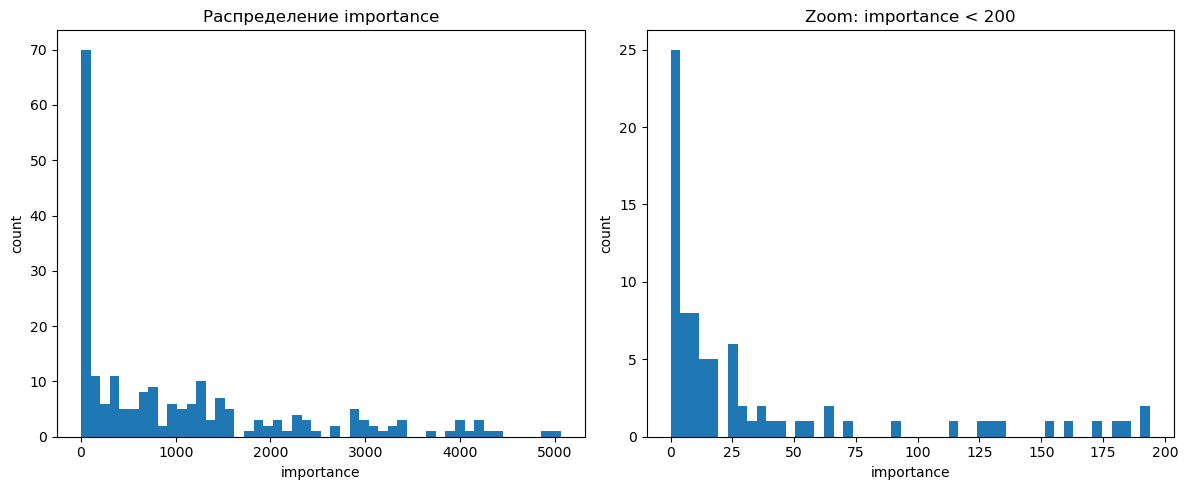

importance <= 0: 16 фич
importance <= 10: 39 фич
importance <= 20: 51 фич
importance <= 50: 64 фич
importance <= 100: 70 фич
importance <= 200: 81 фич


In [36]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(importance['importance'], bins=50)
plt.title('Распределение importance')
plt.xlabel('importance')
plt.ylabel('count')

plt.subplot(1, 2, 2)
plt.hist(importance[importance['importance'] < 200]['importance'], bins=50)
plt.title('Zoom: importance < 200')
plt.xlabel('importance')
plt.ylabel('count')

plt.tight_layout()
plt.show()

# Разбивка по порогам
for threshold in [0, 10, 20, 50, 100, 200]:
    count = (importance['importance'] <= threshold).sum()
    print(f"importance <= {threshold}: {count} фич")

Определяю колонки с 0 важностью и проверяю изменится ли результат если их убрать

In [26]:
zero_importance = importance[importance['importance'] == 0]
print(f"Фичей с importance=0: {len(zero_importance)}")
print(zero_importance['feature'].tolist())

Фичей с importance=0: 16
['enc_loans_account_cur_first', 'enc_loans_account_cur_last', 'pre_fterm_share_rare_bins', 'pre_loans90_last', 'pre_loans3060_first', 'pre_loans_max_overdue_sum_share_rare_bins', 'pre_loans90_changed_ever', 'pre_loans6090_nunique', 'pre_loans6090_first', 'pre_loans6090_last', 'pre_loans6090_change_count', 'pre_loans6090_changed_ever', 'pre_loans6090_share_global_mode', 'pre_loans6090_share_rare_bins', 'pre_loans90_first', 'pre_since_confirmed_share_rare_bins']


In [27]:
zero_cols = [
    'enc_loans_account_cur_first', 'enc_loans_account_cur_last',
    'pre_fterm_share_rare_bins', 'pre_loans90_last',
    'pre_loans3060_first', 'pre_loans_max_overdue_sum_share_rare_bins',
    'pre_loans90_changed_ever', 'pre_loans6090_nunique',
    'pre_loans6090_first', 'pre_loans6090_last',
    'pre_loans6090_change_count', 'pre_loans6090_changed_ever',
    'pre_loans6090_share_global_mode', 'pre_loans6090_share_rare_bins',
    'pre_loans90_first', 'pre_since_confirmed_share_rare_bins'
]

In [52]:
X_sample_reduced = X_train_scaled.drop(columns=zero_cols, errors='ignore')

In [29]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_sample_reduced, y_train,
    test_size    = 0.15,
    stratify     = y_train,
    random_state = RANDOM_SEED
)

In [32]:
final_model_test = lgb.LGBMClassifier(**best_params_final)
final_model_test.fit(
    X_tr, y_tr,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(500)
    ]
)

[500]	valid_0's binary_logloss: 0.140811
[1000]	valid_0's binary_logloss: 0.139732
[1500]	valid_0's binary_logloss: 0.139213
[2000]	valid_0's binary_logloss: 0.138909
[2500]	valid_0's binary_logloss: 0.138692
[3000]	valid_0's binary_logloss: 0.138533
[3500]	valid_0's binary_logloss: 0.138414
[4000]	valid_0's binary_logloss: 0.138315
[4500]	valid_0's binary_logloss: 0.138233
[5000]	valid_0's binary_logloss: 0.138178
[5500]	valid_0's binary_logloss: 0.13813
[6000]	valid_0's binary_logloss: 0.138091
[6500]	valid_0's binary_logloss: 0.138056
[7000]	valid_0's binary_logloss: 0.138028


NameError: name 'y_pred' is not defined

In [33]:
y_pred_test = final_model_test.predict_proba(X_val)[:, 1]
print(f"Финальный ROC-AUC на валидации: {roc_auc_score(y_val, y_pred_test):.4f}")
print(f"Использовано деревьев: {final_model_test.best_iteration_}")

Финальный ROC-AUC на валидации: 0.7547
Использовано деревьев: 7156


Абсолютно не поменялся результат что логично, можно пересобрать пайплайн что бы не создавать эти фичи

In [40]:
importance_test = pd.DataFrame({
    'feature'   : X_sample_reduced.columns,
    'importance': final_model_test.feature_importances_
}).sort_values('importance', ascending=False)

In [42]:
zero_importance_test = importance_test[importance_test['importance'] <= 10]
print(f"Фичей с importance=0: {len(zero_importance_test)}")
print(zero_importance_test['feature'].tolist())

Фичей с importance=0: 20
['is_single_credit', 'loans5_has_overdue', 'enc_loans_account_cur_changed_ever', 'pre_loans90_nunique', 'pre_loans3060_changed_ever', 'pre_pterm_changed_ever', 'loans530_has_overdue', 'maxover2limit_has_nonzero', 'pre_loans5_first', 'over2limit_has_nonzero', 'pre_loans90_share_global_mode', 'pre_loans_credit_limit_changed_ever', 'loans90_has_overdue', 'pre_loans530_changed_ever', 'loans6090_has_overdue', 'overdue90_first_vs_last', 'util_has_nonzero', 'pre_loans5_changed_ever', 'paym_row_last_max', 'pre_loans3060_last']


In [43]:
col_lower_10 = ['is_single_credit', 'loans5_has_overdue', 'enc_loans_account_cur_changed_ever', 'pre_loans90_nunique', 'pre_loans3060_changed_ever', 'pre_pterm_changed_ever', 'loans530_has_overdue', 'maxover2limit_has_nonzero', 'pre_loans5_first', 'over2limit_has_nonzero', 'pre_loans90_share_global_mode', 'pre_loans_credit_limit_changed_ever', 'loans90_has_overdue', 'pre_loans530_changed_ever', 'loans6090_has_overdue', 'overdue90_first_vs_last', 'util_has_nonzero', 'pre_loans5_changed_ever', 'paym_row_last_max', 'pre_loans3060_last']

In [53]:
X_sample_reduced = X_sample_reduced.drop(columns=col_lower_10, errors='ignore')

X_tr, X_val, y_tr, y_val = train_test_split(
    X_sample_reduced, y_train,
    test_size    = 0.15,
    stratify     = y_train,
    random_state = RANDOM_SEED
)

In [54]:
final_model_test = lgb.LGBMClassifier(**best_params_final)
final_model_test.fit(
    X_tr, y_tr,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(500)
    ]
)

[500]	valid_0's binary_logloss: 0.140826
[1000]	valid_0's binary_logloss: 0.139751
[1500]	valid_0's binary_logloss: 0.139226
[2000]	valid_0's binary_logloss: 0.13891
[2500]	valid_0's binary_logloss: 0.138694
[3000]	valid_0's binary_logloss: 0.138531
[3500]	valid_0's binary_logloss: 0.138415
[4000]	valid_0's binary_logloss: 0.138322
[4500]	valid_0's binary_logloss: 0.138241
[5000]	valid_0's binary_logloss: 0.138185
[5500]	valid_0's binary_logloss: 0.138135
[6000]	valid_0's binary_logloss: 0.138105
[6500]	valid_0's binary_logloss: 0.138074


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,8000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [55]:
y_pred_test = final_model_test.predict_proba(X_val)[:, 1]
print(f"Финальный ROC-AUC на валидации: {roc_auc_score(y_val, y_pred_test):.4f}")
print(f"Использовано деревьев: {final_model_test.best_iteration_}")

Финальный ROC-AUC на валидации: 0.7543
Использовано деревьев: 6554


показатель незначительно снизился

In [59]:
importance_test = pd.DataFrame({
    'feature'   : X_sample_reduced.columns,
    'importance': final_model_test.feature_importances_
}).sort_values('importance', ascending=False)

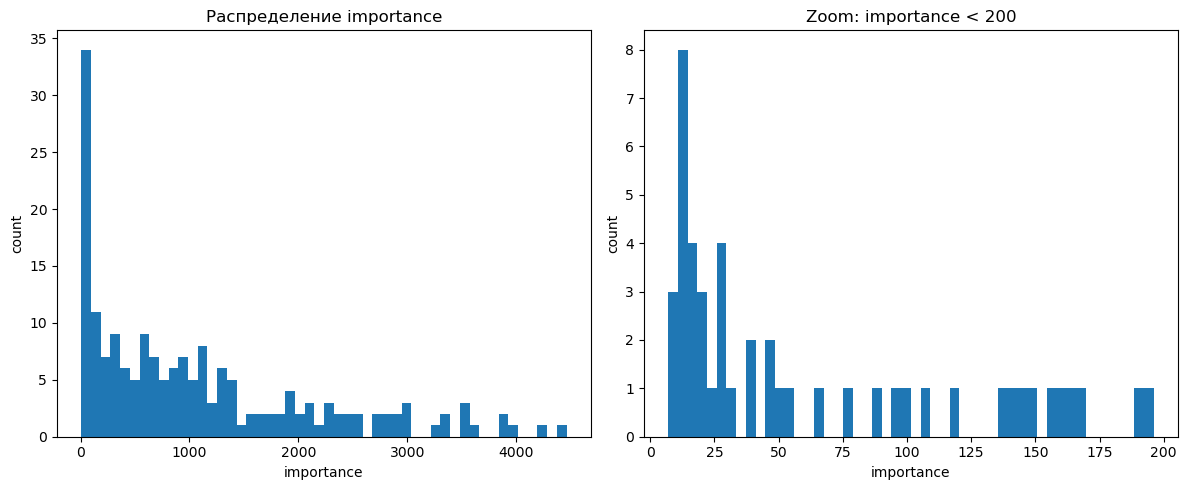

importance <= 0: 0 фич
importance <= 10: 3 фич
importance <= 20: 15 фич
importance <= 50: 29 фич
importance <= 100: 35 фич
importance <= 200: 47 фич


In [60]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(importance_test['importance'], bins=50)
plt.title('Распределение importance')
plt.xlabel('importance')
plt.ylabel('count')

plt.subplot(1, 2, 2)
plt.hist(importance_test[importance_test['importance'] < 200]['importance'], bins=50)
plt.title('Zoom: importance < 200')
plt.xlabel('importance')
plt.ylabel('count')

plt.tight_layout()
plt.show()

# Разбивка по порогам
for threshold in [0, 10, 20, 50, 100, 200]:
    count = (importance_test['importance'] <= threshold).sum()
    print(f"importance <= {threshold}: {count} фич")

In [61]:
zero_importance_test = importance_test[importance_test['importance'] <= 20]
print(f"Фичей с importance=0: {len(zero_importance_test)}")
print(zero_importance_test['feature'].tolist())

Фичей с importance=0: 15
['pre_over2limit_changed_ever', 'pre_till_pclose_changed_ever', 'pre_fterm_changed_ever', 'has_serious_overdue', 'pclose_flag_any', 'pre_loans3060_nunique', 'fclose_flag_any', 'enc_loans_account_holder_type_changed_ever', 'enc_loans_credit_status_changed_ever', 'enc_loans_account_holder_type_last', 'pre_till_fclose_changed_ever', 'pre_loans3060_share_global_mode', 'loans3060_has_overdue', 'pre_maxover2limit_changed_ever', 'pre_loans_next_pay_summ_changed_ever']


In [62]:
col_lower_20 = ['pre_over2limit_changed_ever', 'pre_till_pclose_changed_ever', 'pre_fterm_changed_ever', 'has_serious_overdue', 'pclose_flag_any', 'pre_loans3060_nunique', 'fclose_flag_any', 'enc_loans_account_holder_type_changed_ever', 'enc_loans_credit_status_changed_ever', 'enc_loans_account_holder_type_last', 'pre_till_fclose_changed_ever', 'pre_loans3060_share_global_mode', 'loans3060_has_overdue', 'pre_maxover2limit_changed_ever', 'pre_loans_next_pay_summ_changed_ever']

In [63]:
X_sample_reduced = X_sample_reduced.drop(columns=col_lower_20, errors='ignore')

X_tr, X_val, y_tr, y_val = train_test_split(
    X_sample_reduced, y_train,
    test_size    = 0.15,
    stratify     = y_train,
    random_state = RANDOM_SEED
)

In [64]:
final_model_test = lgb.LGBMClassifier(**best_params_final)
final_model_test.fit(
    X_tr, y_tr,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(500)
    ]
)

[500]	valid_0's binary_logloss: 0.140805
[1000]	valid_0's binary_logloss: 0.139748
[1500]	valid_0's binary_logloss: 0.139225
[2000]	valid_0's binary_logloss: 0.138916
[2500]	valid_0's binary_logloss: 0.138704
[3000]	valid_0's binary_logloss: 0.138533
[3500]	valid_0's binary_logloss: 0.138414
[4000]	valid_0's binary_logloss: 0.13832
[4500]	valid_0's binary_logloss: 0.138242
[5000]	valid_0's binary_logloss: 0.138191
[5500]	valid_0's binary_logloss: 0.138132
[6000]	valid_0's binary_logloss: 0.138092
[6500]	valid_0's binary_logloss: 0.138058
[7000]	valid_0's binary_logloss: 0.138029


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,8000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [66]:
y_pred_test = final_model_test.predict_proba(X_val)[:, 1]
print(f"Финальный ROC-AUC на валидации: {roc_auc_score(y_val, y_pred_test):.4f}")
print(f"Использовано деревьев: {final_model_test.best_iteration_}")

Финальный ROC-AUC на валидации: 0.7547
Использовано деревьев: 7285


Метрика даже выросла немного

In [67]:
importance_test = pd.DataFrame({
    'feature'   : X_sample_reduced.columns,
    'importance': final_model_test.feature_importances_
}).sort_values('importance', ascending=False)

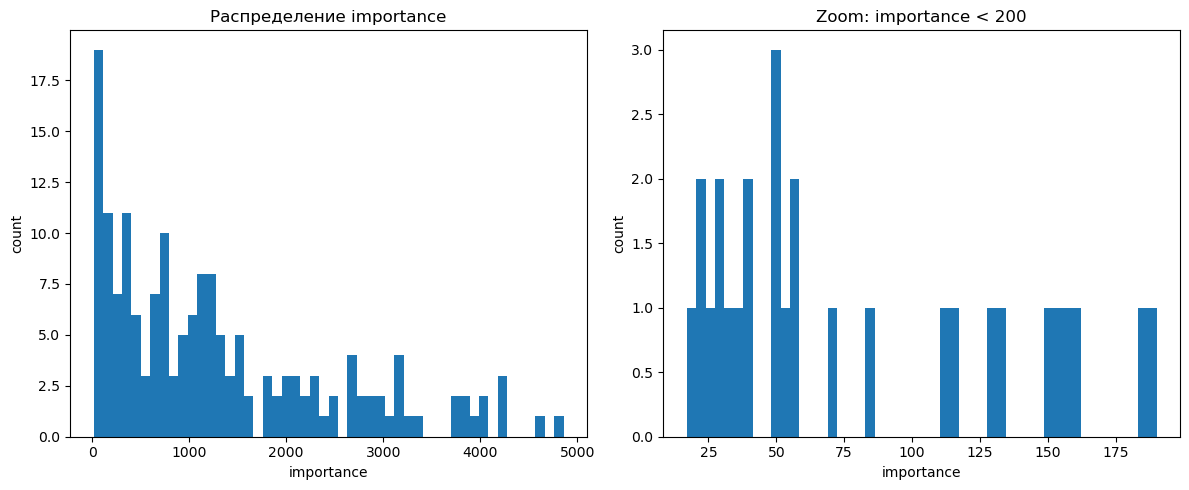

importance <= 0: 0 фич
importance <= 10: 0 фич
importance <= 20: 1 фич
importance <= 50: 12 фич
importance <= 100: 18 фич
importance <= 200: 28 фич


In [68]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(importance_test['importance'], bins=50)
plt.title('Распределение importance')
plt.xlabel('importance')
plt.ylabel('count')

plt.subplot(1, 2, 2)
plt.hist(importance_test[importance_test['importance'] < 200]['importance'], bins=50)
plt.title('Zoom: importance < 200')
plt.xlabel('importance')
plt.ylabel('count')

plt.tight_layout()
plt.show()

# Разбивка по порогам
for threshold in [0, 10, 20, 50, 100, 200]:
    count = (importance_test['importance'] <= threshold).sum()
    print(f"importance <= {threshold}: {count} фич")

фич с 0 важностью не осталось 20-200 адекватные по весу фичу, больше удалять не буду

In [101]:
# Смотрим на базовые признаки
base_cols = ['num_credits', 'max_rn', 'rn_span', 'pclose_flag_share', 'fclose_flag_share']
print(importance_test[importance_test['feature'].isin(base_cols)].to_string())

# Смотрим на overdue признаки
overdue_cols = [c for c in importance_test['feature'] if 'overdue' in c or 'loans5' in c or 'loans530' in c or 'loans3060' in c or 'loans90' in c]
print(importance_test[importance_test['feature'].isin(overdue_cols)].to_string())

# Смотрим на util признаки  
util_cols = [c for c in importance_test['feature'] if 'util' in c or 'over2limit' in c or 'maxover2limit' in c]
print(importance_test[importance_test['feature'].isin(util_cols)].to_string())

             feature  importance
4  fclose_flag_share        2079
3  pclose_flag_share        1821
0        num_credits         375
2            rn_span         347
1             max_rn         342
                                         feature  importance
22                             share_any_overdue        2965
11                        loans530_overdue_share        1625
10                          loans5_overdue_share        1548
119  pre_loans_max_overdue_sum_share_global_mode        1529
6                            loans530_zero_share        1381
7                           loans3060_zero_share        1203
5                              loans5_zero_share        1153
12                       loans3060_overdue_share        1118
20                         share_serious_overdue        1059
162                     serious_overdue_fraction         960
24                             count_any_overdue         740
14                         loans90_overdue_share         729
137      

проверяю мультиколлинеарные фичи на их важность в модели

In [69]:
# фичи под удаление из процесса
all_cols = set(zero_cols + col_lower_10 + col_lower_20)

In [70]:
all_cols

{'enc_loans_account_cur_changed_ever',
 'enc_loans_account_cur_first',
 'enc_loans_account_cur_last',
 'enc_loans_account_holder_type_changed_ever',
 'enc_loans_account_holder_type_last',
 'enc_loans_credit_status_changed_ever',
 'fclose_flag_any',
 'has_serious_overdue',
 'is_single_credit',
 'loans3060_has_overdue',
 'loans530_has_overdue',
 'loans5_has_overdue',
 'loans6090_has_overdue',
 'loans90_has_overdue',
 'maxover2limit_has_nonzero',
 'over2limit_has_nonzero',
 'overdue90_first_vs_last',
 'paym_row_last_max',
 'pclose_flag_any',
 'pre_fterm_changed_ever',
 'pre_fterm_share_rare_bins',
 'pre_loans3060_changed_ever',
 'pre_loans3060_first',
 'pre_loans3060_last',
 'pre_loans3060_nunique',
 'pre_loans3060_share_global_mode',
 'pre_loans530_changed_ever',
 'pre_loans5_changed_ever',
 'pre_loans5_first',
 'pre_loans6090_change_count',
 'pre_loans6090_changed_ever',
 'pre_loans6090_first',
 'pre_loans6090_last',
 'pre_loans6090_nunique',
 'pre_loans6090_share_global_mode',
 'pre_lo

# Pipepline

In [300]:
class CreditScoringPipeline:

    def __init__(self, model_params, rare_threshold=0.05):
        self.model_params   = model_params
        self.rare_threshold = rare_threshold
        self.aggregator_    = None
        self.scaler_        = None
        self.model_         = None
        self.feature_cols_  = None

    def _feature_engineering(self, X):
        X = X.copy()
        X['serious_to_mild_ratio'] = (
            X['loans90_overdue_share'] /
            X['loans5_overdue_share'].replace(0, np.nan)
        ).fillna(0)
        X['serious_overdue_fraction'] = (
            X['count_serious_overdue'] /
            X['count_any_overdue'].replace(0, np.nan)
        ).fillna(0)
        X['util_first_vs_last'] = X['pre_util_last'] - X['pre_util_first']
        X['outstanding_trend']  = X['pre_loans_outstanding_last'] - X['pre_loans_outstanding_first']
        X['credit_limit_trend'] = X['pre_loans_credit_limit_last'] - X['pre_loans_credit_limit_first']
        return X

    def fit(self, raw_df, y):
        # 1. Агрегация
        self.aggregator_ = CreditHistoryAggregatorFast(
            rare_threshold=self.rare_threshold
        )
        self.aggregator_.update_global_stats(raw_df)
        self.aggregator_.finalize_global_stats()
        agg_df = self.aggregator_.transform(raw_df)

        # 2. Убираем id
        X = agg_df.drop(columns=['id'])

        # 3. Фича инжиниринг
        X = self._feature_engineering(X)

        # 4. Запоминаем порядок колонок
        self.feature_cols_ = X.columns.tolist()

        # 5. Скейлер
        self.scaler_ = StandardScaler()
        X_scaled = pd.DataFrame(
            self.scaler_.fit_transform(X),
            columns=self.feature_cols_
        )

        # 6. Модель
        self.model_ = lgb.LGBMClassifier(**self.model_params)
        self.model_.fit(X_scaled, y)

        print(f"Pipeline fitted! Фич: {len(self.feature_cols_)}")
        return self

    def predict(self, raw_df):
        # 1. Агрегация
        agg_df = self.aggregator_.transform(raw_df)
        ids    = agg_df['id']
        X      = agg_df.drop(columns=['id'])

        # 2. Фича инжиниринг
        X = self._feature_engineering(X)

        # 3. Порядок колонок как при обучении
        X = X[self.feature_cols_]

        # 4. Скейлинг
        X_scaled = pd.DataFrame(
            self.scaler_.transform(X),
            columns=self.feature_cols_
        )

        # 5. Предикт
        proba = self.model_.predict_proba(X_scaled)[:, 1]

        return pd.DataFrame({'id': ids.values, 'flag': proba})


# Создаём пайплайн и вставляем уже обученные объекты
pipeline = CreditScoringPipeline(model_params=best_params_final)
pipeline.aggregator_   = agg
pipeline.scaler_       = scaler
pipeline.model_        = final_model
pipeline.feature_cols_ = X_train_scaled.columns.tolist()

In [301]:
with open('credit_pipeline.pkl', 'wb') as f:
    dill.dump(pipeline, f)

In [302]:
with open('credit_pipeline.pkl', 'rb') as f:
    loaded = dill.load(f)